# Urban Sounds Classification Project
##### Trabalho realizado por: Francisco Tavares, Rodrigo Batista e Rodrigo Taveira

## Índice <a id="Índice"></a>
1. [Introdução](#introdução)
2. [Análise dos Dados Metadata](#análise-dos-dados-metadata)
3. [Implementação do MLP](#implementação-do-mlp)
    - [Extração de Features](#extração-de-features)
    - [Divisão treino/teste](#divisão-treinoteste)
    - [Criação do modelo](#criação-do-modelo)
    - [Treino de hiperparâmetros](#treino-de-hiperparâmentros)
    - [Teste Final do Modelo](#teste-final-do-modelo)
4. [Implementação do CNN](#implementação-do-cnn)
    - [Arquitetura da Rede](#arquitetura-da-rede)
    - [Hiperparâmetros Utilizados](#hiperparâmetros-utilizados)
    - [Justificação dos Resultados Obtidos com Espectogramas](#justificação-dos-resultados-obtidos-espectogramas)
    - [Justificação dos Resultados Obtidos com MFCC](#justificação-dos-resultados-obtidos-MFCC)
5. [Testes Estatísticos](#teste-estatisticos)
6. [Discussão de Resultados dos testes](#discussão-de-resultados-dos-testes)
7. [Conclusão](#conclusão)

## Introdução <a id="introducao"></a>


Este trabalho tem como objetivo desenvolver um modelo de aprendizagem profundo para classificação de sons utilizando o UrbanSound8K, um dataset amplamente utilizado para análise de áudio urbano. 
Este dataset contém um total de 8732 audio recordings de sons urbanos, cada com uma duração até 4 segundos. Cada excerto está classificado com uma das seguintes classes:
- 0 = air_conditioner
- 1 = car_horn
- 2 = children_playing
- 3 = dog_bark
- 4 = drilling
- 5 = engine_idling
- 6 = gun_shot
- 7 = jackhammer
- 8 = siren
- 9 = street_music

O objetivo deste projecto assenta em definir, compilar, treinar e avaliar dois classificadores de Deep Learning. Os modelos  de Deep Learning a ser considerados são: 
- Multilayer Perceptron (MLP)
- Convolutional Neural Network (CNN)
- Recurrent Neural Network (RNN)

Neste notebook,nós vamos nos focar no desenvolvimento do MLP e do CNN.


### Análise dos Dados Metadata

In [2]:
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import soundfile as sf
from scipy.stats import skew, kurtosis, shapiro, ttest_rel
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
from tensorflow.keras.regularizers import l2,l1
from foolbox import TensorFlowModel, accuracy
from foolbox.attacks import L2DeepFoolAttack
from foolbox.criteria import Misclassification
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
import tensorflow.keras.backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [42]:
df = pd.read_csv("UrbanSound8k.csv")
df

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
...,...,...,...,...,...,...,...,...
8727,99812-1-2-0.wav,99812,159.522205,163.522205,2,7,1,car_horn
8728,99812-1-3-0.wav,99812,181.142431,183.284976,2,7,1,car_horn
8729,99812-1-4-0.wav,99812,242.691902,246.197885,2,7,1,car_horn
8730,99812-1-5-0.wav,99812,253.209850,255.741948,2,7,1,car_horn


Vamos ver agora a distribuição da nossa classe target

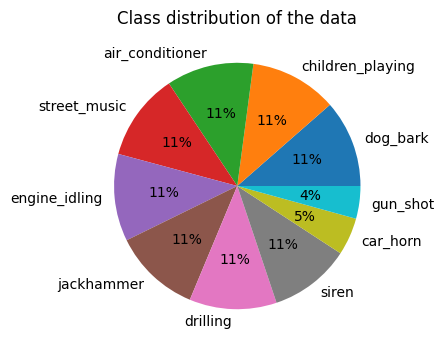

In [43]:
df['class'].value_counts().plot(kind='pie', autopct='%1.0f%%', figsize=(4,4))
plt.title('Class distribution of the data')
plt.ylabel('')
plt.show()

#### Padronização e Resampling

Modelos de aprendizagem profunda como o MLP exigem que os dados de entrada tenham dimensões consistentes. Áudios com durações variadas resultam em diferentes números de amostras ou features, dificultando o processamento em batching. Desta forma, decidimos padronizar os áudios para a duração fixa de 4 segundos repetindo os áudios até atingirem essa marca.

Padronizar a duração dos áudios permite que todas as amostras tenham o mesmo espaço temporal para análise, garantindo que as características extraídas sejam comparáveis. 

Foi também realizado resampling para ajustar a taxa de amostragem para um valor específico, que neste caso foi 22500 . A taxa de amostragem define o número de amostras por segundo do áudio e tem um impacto direto na qualidade e quantidade de dados disponíveis.


In [44]:
"""""
input_path = "UrbanSound8K/audio"

# Array de pastas para analisar
folders_to_analyze = [folder for folder in os.listdir(input_path)]
folders_to_analyze.sort()  # Ordena as pastas
print(folders_to_analyze)

target_duration = 4.0

def repeat_audio_to_duration(y, sr, target_duration):
    original_duration = librosa.get_duration(y=y, sr=sr)
    while original_duration < target_duration:
        y = np.concatenate([y, y])
        original_duration = librosa.get_duration(y=y, sr=sr)
    y = y[:int(target_duration * sr)]
    return y

# Processamento dos arquivos de áudio
for audio_folder in folders_to_analyze:
    audio_folder_path = os.path.join(input_path, audio_folder)

    if os.path.isdir(audio_folder_path):
        for audio in os.listdir(audio_folder_path):
            # Verifique se o arquivo é `.wav`
            if audio.endswith('.wav'):
                audio_file_path = os.path.join(audio_folder_path, audio)

                try:
                    # Carregar o arquivo de áudio
                    y, sr = librosa.load(audio_file_path, sr=None)

                    # Criar pasta de saída
                    output_folder_path = os.path.join(input_path, f"{audio_folder}_4sec")
                    os.makedirs(output_folder_path, exist_ok=True)

                    # Ajustar duração do áudio
                    if librosa.get_duration(y=y, sr=sr) != target_duration:
                        y = repeat_audio_to_duration(y, sr, target_duration)
                        print(f"Áudio ajustado para {target_duration} segundos e salvo em {output_folder_path}")
                    else:
                        print(f"Áudio já possui {target_duration} segundos, salvo em {output_folder_path}")

                    # Salvar o arquivo ajustado
                    sf.write(os.path.join(output_folder_path, audio), y, sr)

                except Exception as e:
                    print(f"Erro ao carregar {audio}: {e}")
"""""

'""\nimport os\nimport librosa\nimport numpy as np\nimport soundfile as sf\n\ninput_path = "UrbanSound8K/audio"\n\n# Array de pastas para analisar\nfolders_to_analyze = [folder for folder in os.listdir(input_path)]\nfolders_to_analyze.sort()  # Ordena as pastas\nprint(folders_to_analyze)\n\ntarget_duration = 4.0\n\ndef repeat_audio_to_duration(y, sr, target_duration):\n    original_duration = librosa.get_duration(y=y, sr=sr)\n    while original_duration < target_duration:\n        y = np.concatenate([y, y])\n        original_duration = librosa.get_duration(y=y, sr=sr)\n    y = y[:int(target_duration * sr)]\n    return y\n\n# Processamento dos arquivos de áudio\nfor audio_folder in folders_to_analyze:\n    audio_folder_path = os.path.join(input_path, audio_folder)\n\n    if os.path.isdir(audio_folder_path):\n        for audio in os.listdir(audio_folder_path):\n            # Verifique se o arquivo é `.wav`\n            if audio.endswith(\'.wav\'):\n                audio_file_path = os.pa

## Implementação do MLP <a id="Implementação do MLP"></a>
[Voltar ao índice](#Índice)

O Multilayer Perceptron (MLP) é uma estrutura fundamental das redes neuronais artificiais, desenvolvida para aprender relações complexas e não lineares dos dados. Esta é uma rede feedforward, composta por uma camada de entrada, uma ou mais camadas ocultas e uma camada de saída, sendo que cada uma está totalmente conectada à seguinte. As camadas utilizam funções de ativação para introduzir não linearidade, permitindo que o modelo capture padrões mais sofisticados. O MLP é bastante utilizado em tarefas de classificação, mostrando-se eficaz na análise e modelagem de dados.

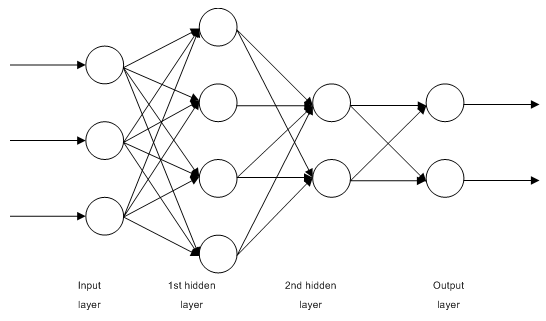

In [36]:
# Carregar os dados
features_df = pd.read_csv('urban_sound_features.csv')
metadata_df = pd.read_csv('UrbanSound8K.csv')
df = pd.merge(features_df, metadata_df, left_on='slice_file_name', right_on='slice_file_name', how='left')

# Configurações
num_classes = 10
unique_folds = df['fold_y'].unique()


### Extração de Features
[Voltar ao Índice](#índice)

O uso de features como os MFCCs, Chorma, Mel Spectrogram e Spectral Contrast permite representar informações acústicas importantes de forma compacta, reduzindo a quantidade de dados desnecessários ou redundantes para o modelo. Em vez de processar diretamente o sinal bruto do áudio, as features capturam apenas os aspetos mais relevantes.

In [ ]:
'''''
# Função para extrair diversas features de um arquivo de áudio
def extract_features_from_file(file_path, n_mfcc=13):
    try:
        # Carregar o áudio usando uma taxa de amostragem padrão
        y, sr = librosa.load(file_path, sr=22050)  # Reamostragem para evitar problemas de Nyquist
        
        # Definir os limites de frequência
        fmin = 50
        fmax = sr / 2  # Frequência de Nyquist
        
        # 1. Extrair MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc, axis=1)  # Média de cada MFCC ao longo do tempo
        
        # 2. Extrair Chroma com limites de frequência
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12)
        chroma_mean = np.mean(chroma, axis=1)
        
        # 3. Extrair Mel Spectrogram com número reduzido de bandas
        mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=fmin, fmax=fmax)
        mel_mean = np.mean(mel_spectrogram, axis=1)
        
        # 4. Extrair Spectral Contrast
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=fmin)
        spectral_contrast_mean = np.mean(spectral_contrast, axis=1)
        
        # Concatenar todas as features extraídas
        features = np.hstack((
            mfcc_mean,          # 13 MFCC
            chroma_mean,        # 12 Chroma
            mel_mean[:40],      # 40 Mel Spectrogram bands
            spectral_contrast_mean  # 7 Spectral Contrast
        ))
        
        return features

    except Exception as e:
        print(f"Erro ao processar o arquivo {file_path}: {e}")
        return None


folds = [f"fold{i}" for i in range(1, 11)]

# Dataframe para armazenar todas as features extraídas
all_features = []

# Iterar sobre cada pasta
for fold in folds:
    fold_path = os.path.join(r"ProcessedAudio\repeat", fold)
    
    if os.path.exists(fold_path):
        # Listar todos os arquivos dentro da pasta
        for filename in os.listdir(fold_path):
            file_path = os.path.join(fold_path, filename)
            if os.path.isfile(file_path) and filename.endswith(".npy"):
                # Extrair features do arquivo de áudio
                features = extract_features_from_file(file_path)
                if features is not None:
                    # Adicionar o nome da pasta (fold) e o nome do arquivo à lista de features
                    features = np.append(features, [fold, filename])
                    all_features.append(features)
    else:
        print(f"Pasta {fold_path} não encontrada!")


mfcc_columns = [f'mfcc_{i+1}' for i in range(13)]
chroma_columns = [f'chroma_{i+1}' for i in range(12)]
mel_columns = [f'mel_{i+1}' for i in range(40)]
spectral_contrast_columns = [f'spectral_contrast_{i+1}' for i in range(7)]
columns = mfcc_columns + chroma_columns + mel_columns + spectral_contrast_columns + ['fold', 'filename']

df = pd.DataFrame(all_features, columns=columns)

df.to_csv('urban_sound_features2.csv', index=False)

print("Extração de features concluída e salva em urban_sound_features.csv!")
'''''

MFCC (Mel-Frequency Cepstral Coefficients) - Os MFCCs são uma representação compacta das características de um som, extraindo informações relacionadas à percepção auditiva humana.
Em análise de áudio, normalmente 13 coeficientes são usados (às vezes até 20), porque se descobriu empiricamente que os primeiros coeficientes carregam a maior parte da informação relevante para tarefas de classificação de áudio.

Chroma Features (Cromagrama) - As Chroma Features representam a energia distribuída ao longo de cada uma das 12 notas da escala cromática ocidental, e é comum em tarefas como identificação de acordes ou análise de harmonia musical.

Mel Spectrogram (Espectrograma em escala Mel) - O Mel Spectrogram é uma representação da potência espectral do som em uma escala de frequência mel, que reflete melhor como os humanos percebem a frequência sonora. Normalmente, são escolhidos entre 20 a 40 filtros de Mel, dependendo da resolução desejada. Neste caso, foi escolhido 40 para capturar mais detalhes das características de frequência, fornecendo uma boa discriminação entre diferentes tipos de sons

Spectral Contrast (Contraste Espectral) - Mede a diferença de energia entre os picos e os vales no espectro de frequência. Essas características são usadas para distinguir entre diferentes tipos de sons e texturas, como vozes, música e ruídos ambientais.

### Divisão treino/teste

Para a divisão dos dados em treino e teste foi realizada a técnica de cross validation. Este método consiste em usar sistematicamente cada folder para treino e teste. Em cada iteração, 8 folds foram usados para treino, enquanto 1 é reservado para validação e 1 para teste. Este processo é repetido 10 vezes, garantindo que cada fold seja usado exatamente uma vez como conjunto de teste.

Este método permite que divisão estática entre treino e teste possa ser evitada. Assim é possivel generalizar de forma mais eficaz em diferentes subconjuntos de dados.

In [37]:
def prepare_data(df, test_fold, val_fold):

    test_data = df[df['fold_y'] == test_fold]

    val_data = df[df['fold_y'] == val_fold]

    train_data = df[(df['fold_y'] != test_fold) & (df['fold_y'] != val_fold)]

    X_train = train_data.drop(['fold_x', 'fold_y', 'slice_file_name', 'class', 'classID', 
                               'fsID', 'start', 'end', 'salience'], axis=1)
    y_train = train_data['classID']
    X_val = val_data.drop(['fold_x', 'fold_y', 'slice_file_name', 'class', 'classID', 
                           'fsID', 'start', 'end', 'salience'], axis=1)
    y_val = val_data['classID']
    X_test = test_data.drop(['fold_x', 'fold_y', 'slice_file_name', 'class', 'classID', 
                             'fsID', 'start', 'end', 'salience'], axis=1)
    y_test = test_data['classID']

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    encoder = LabelEncoder()
    y_train = to_categorical(encoder.fit_transform(y_train), num_classes=num_classes)
    y_val = to_categorical(encoder.transform(y_val), num_classes=num_classes)
    y_test = to_categorical(encoder.transform(y_test), num_classes=num_classes)

    return X_train, X_val, X_test, y_train, y_val, y_test



### Criação do modelo

A função create_model() define a estrutura da rede neuronal para a classificação.

A camada densa inicial conecta todas as entradas a 256 entradas. Este número que foi escolhido para capturar a alta dimensionalidade das features extraídas. A função de ativação usada foi a ReLU que é amplamente usada nas redes profundas devido à sua eficiência computacional. Como entrada (input_shape) o modelo espera um vetor unidimensional cujo tamanho corresponde ao número de features no conjunto de dados.

A regularização L2 (Lasso) é aplicada para prevenir o overfitting. Esta penaliza grandes valores de pesos, o que ajuda a controlar a complexidade do modelo.

Na segunda camada densa, é reduzido o número de neurônios para 128. Após a extração inicial de características, esta camada começa a condensar a informação para níveis mais abstratos.
Na terceira camada densa, o número de neurônios é reduzido para 64. Esta camada compacta ainda mais os dados, extraindo as informações mais relevantes enquanto elimina redundâncias. 

Para as camadas Dropout, durante o treino esta desativa aleatoriamente 50% dos neurônios desta camada em cada iteração. Este método ajuda a evitar que a rede dependa excessivamente de certos neurônios e, assim, mitiga o overfitting.

A camada de saída é a camada final e é responsável por produzir a previsão. O número de neurônios nesta camada corresponde ao número de classes (10). É usado a função de ativação Softmax que transforma os valores desaída em probabilidades (valores entre 0 e 1) que somam 1.

Desta forma a estrutura do modelo foi projetada cuidadosamente para equilibrar a capacidade de aprendizagem e prevenção de overfitting.


In [38]:
def create_model(l2_value):
    return Sequential([
        Dense(256, activation='relu', input_shape=(X_train.shape[1],),
              kernel_regularizer=l2(l2_value)),
        Dropout(0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(l2_value)),
        Dropout(0.5),
        Dense(64, activation='relu', kernel_regularizer=l2(l2_value)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])


## Treino de hiperparâmentros

O ajuste dos hiperparâmetros é uma etapa essencial no treino de modleos de ML, já que estes controlam aspetam crucias do seu treino e influenciam diretamente a capacidade do modelo generalizar para novos dados.

Durante o treino foram testado diferentes valores para parâmetros como:
 - A taxa de Regularização L2 utilizada para evitar o overfitting, foram testatos diferentes valores para determinar a força ideal da penalizado aplicada aos pesos do modelo. Foi também testado a regularização L1, mas esteve obteve piores resultados então foi deixada de parte.
 - A taxa de dropout foi ajustada par introduzir ruído durante o treino e melhorar a sua robustez.
 - Foi escolhido o otimizador Adam pela sua eficiência na convergência, já que foi o otimizador que obteve melhores resultados em comparação com o SGD.
 - O learning rate que é a atualização dos pesos.
 - Tamanho dos Bacthes, desta forma foi definio o número de amostras processadas antes da atualização dos pesos, assim equilibrando a eficiência computacional e a estabilidade do gradiente.
 - O número de épocas foi ajustado para garantir que o modelo tem tempo suficiente para apredner padrões significativos sem overfitting.
 - O early stopping foi implementado para prevenir overfitting e reduzir o tempo de execução. Este monitoriza a performance do modelo no conjunto de validação ao longo das épocas de treino e interrompe assim que o desempenho comece a estabilizar, indicando que o modelo atingiu o seu limite de aprendizagem.



C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.1228 - loss: 2.6365 - val_accuracy: 0.2275 - val_loss: 2.2694
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1421 - loss: 2.4269 - val_accuracy: 0.3119 - val_loss: 2.2206
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1714 - loss: 2.3244 - val_accuracy: 0.3491 - val_loss: 2.1741
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1970 - loss: 2.2497 - val_accuracy: 0.3773 - val_loss: 2.1202
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2247 - loss: 2.1763 - val_accuracy: 0.3773 - val_loss: 2.0626
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2477 - loss: 2.1176 - val_accuracy: 0.3806 - val_loss: 2.0024
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2762 - loss: 2.0477 - val_accuracy: 0.3975 - val_loss: 1.9426
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2981 - loss: 1.9960 - val_accuracy: 

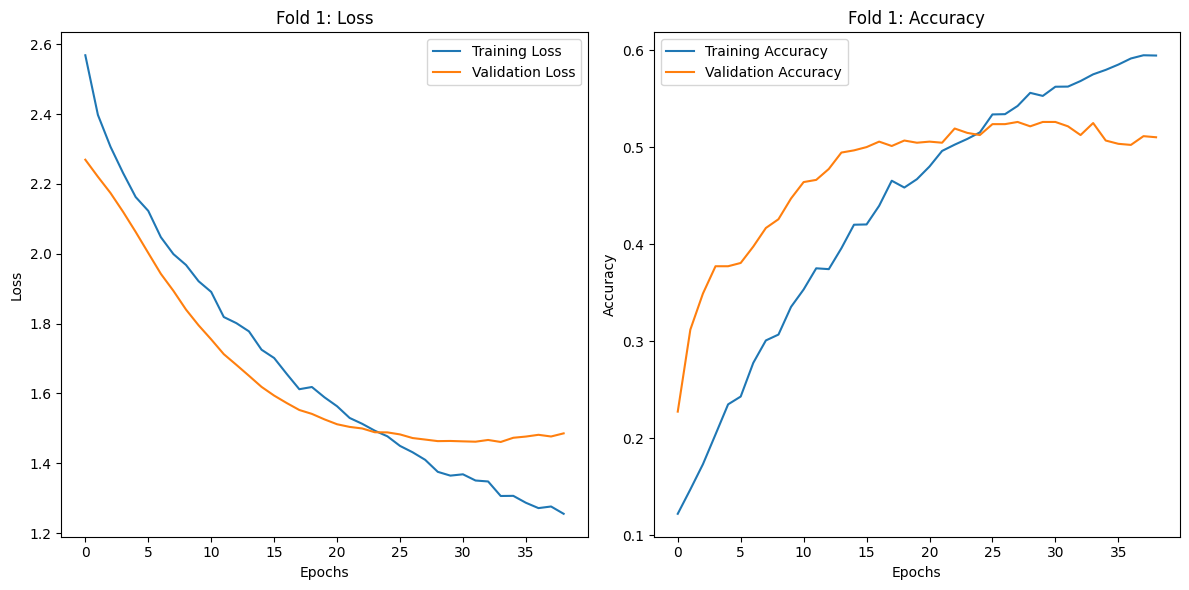

Fold 2: Loss = 1.4610, Accuracy = 0.5248


In [ ]:
epochs = 50
batch_size = 64

test_fold=1
val_fold=2
fold_accuracies = []
fold_losses = []

X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, test_fold, val_fold)

model = create_model(l2_value=0.0001)

model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping],
                    verbose=1)
                    

val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

y_pred = np.argmax(model.predict(X_val), axis=1)
y_true = np.argmax(y_val, axis=1)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title(f'Fold {test_fold}: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f'Fold {test_fold}: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


print(f"Fold {val_fold}: Loss = {val_loss:.4f}, Accuracy = {val_accuracy:.4f}")


Para o teste de hiperparâmetros foram realizados vários testes para encontrar o melhor conjunto de parâmetros. Estes testes foram feitos correndo o código para a primeira iteração e testando no validation fold

### Teste Final do Modelo

Agora já com o tuning dos parâmetros realizado, iremos testar o modelo para as 10 iterações

C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.1044 - loss: 2.6635 - val_accuracy: 0.1926 - val_loss: 2.2913
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1280 - loss: 2.4666 - val_accuracy: 0.2793 - val_loss: 2.2474
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1557 - loss: 2.3494 - val_accuracy: 0.3097 - val_loss: 2.2130
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1683 - loss: 2.3068 - val_accuracy: 0.3345 - val_loss: 2.1772
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1952 - loss: 2.2242 - val_accuracy: 0.3637 - val_loss: 2.1350
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2140 - loss: 2.1933 - val_accuracy: 0.3818 - val_loss: 2.0925
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2301 - loss: 2.1444 - val_accuracy: 0.4155 - val_loss: 2.0375
Epoch 8/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2513 - loss: 2.0865 - val_accuracy: 0.

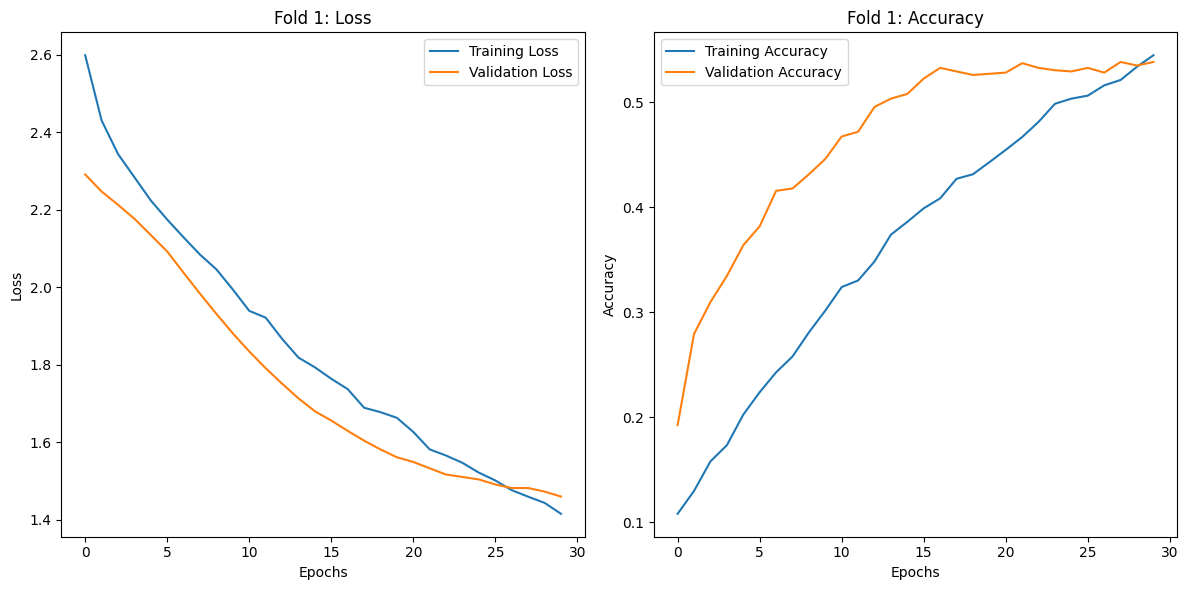

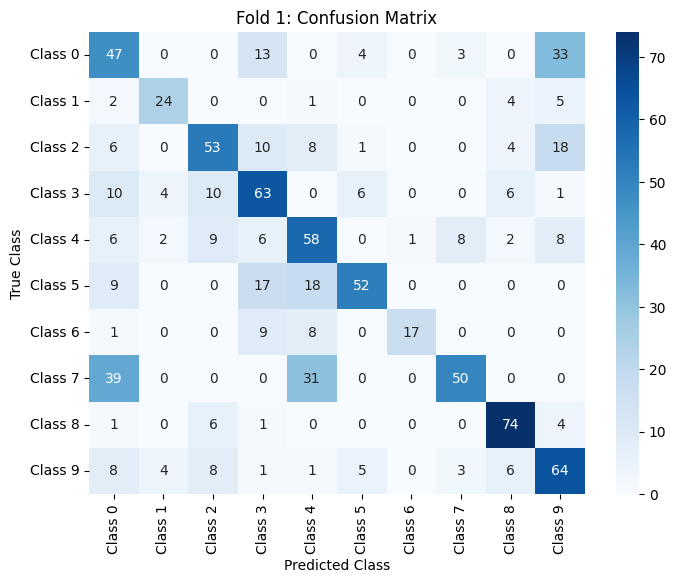

Fold 1: Loss = 1.4719, Accuracy = 0.5750
Epoch 1/30


C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0990 - loss: 2.6654 - val_accuracy: 0.1741 - val_loss: 2.2821
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1378 - loss: 2.4266 - val_accuracy: 0.2335 - val_loss: 2.2292
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1392 - loss: 2.3596 - val_accuracy: 0.2584 - val_loss: 2.1895
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1668 - loss: 2.3169 - val_accuracy: 0.2865 - val_loss: 2.1538
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1876 - loss: 2.2483 - val_accuracy: 0.3059 - val_loss: 2.1109
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2056 - loss: 2.2180 - val_accuracy: 0.3243 - val_loss: 2.0667
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2357 - loss: 2.1541 - val_accuracy: 0.3416 - val_loss: 2.0156
Epoch 8/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2588 - loss: 2.1261 - val_accuracy: 0.3503 - val_

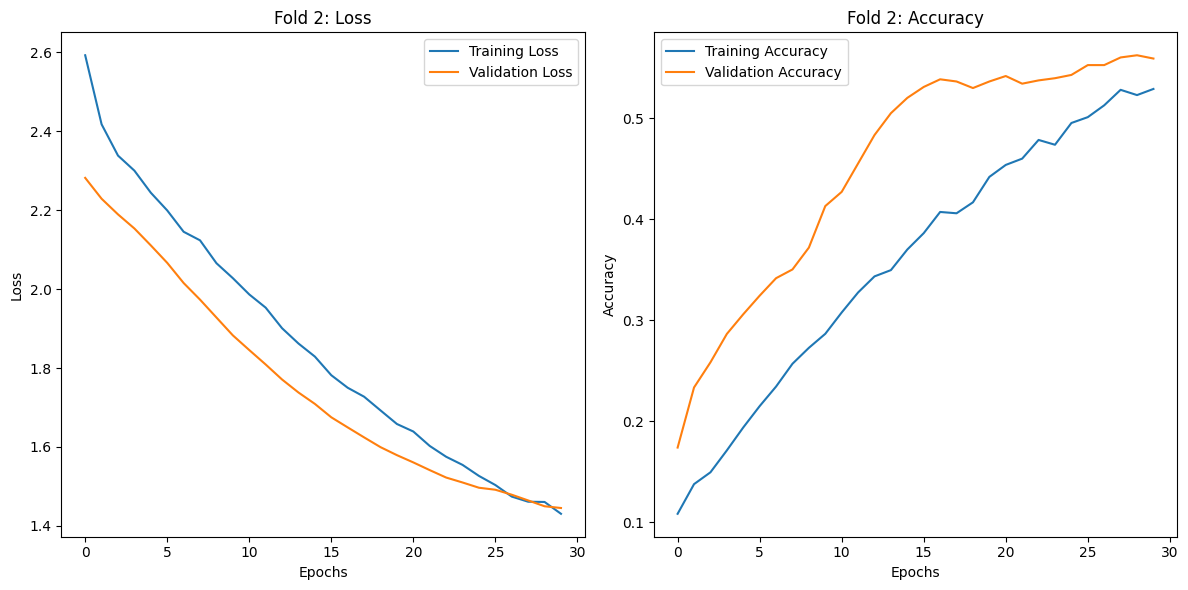

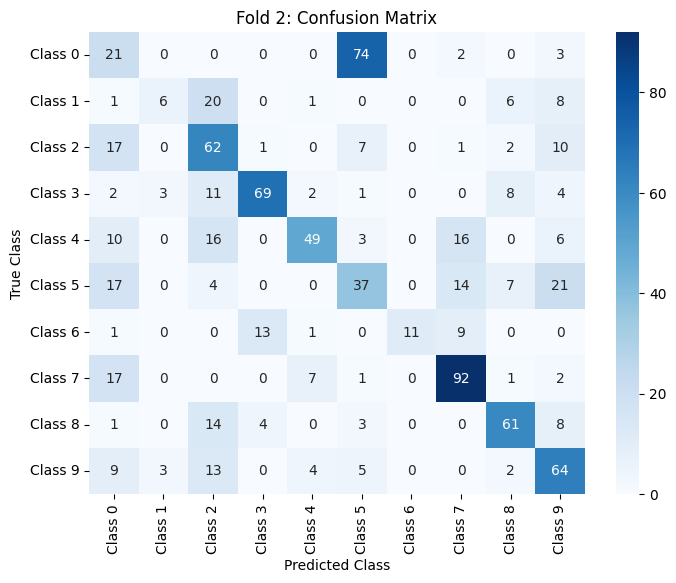

Fold 2: Loss = 1.4826, Accuracy = 0.5315
Epoch 1/30


C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1115 - loss: 2.6711 - val_accuracy: 0.2030 - val_loss: 2.2759
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1394 - loss: 2.4365 - val_accuracy: 0.2667 - val_loss: 2.2127
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1711 - loss: 2.3344 - val_accuracy: 0.3131 - val_loss: 2.1678
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1889 - loss: 2.2621 - val_accuracy: 0.3434 - val_loss: 2.1296
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2083 - loss: 2.2038 - val_accuracy: 0.3657 - val_loss: 2.0825
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2319 - loss: 2.1856 - val_accuracy: 0.3737 - val_loss: 2.0400
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2441 - loss: 2.1180 - val_accuracy: 0.3869 - val_loss: 1.9910
Epoch 8/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2701 - loss: 2.0825 - val_accuracy: 0.4071 - val_

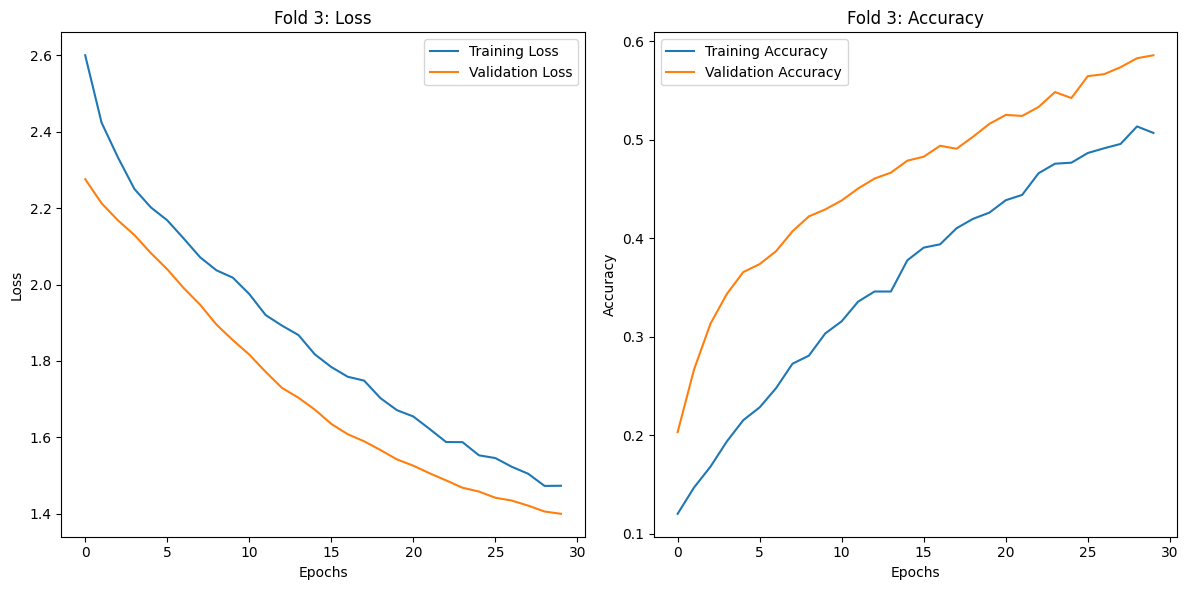

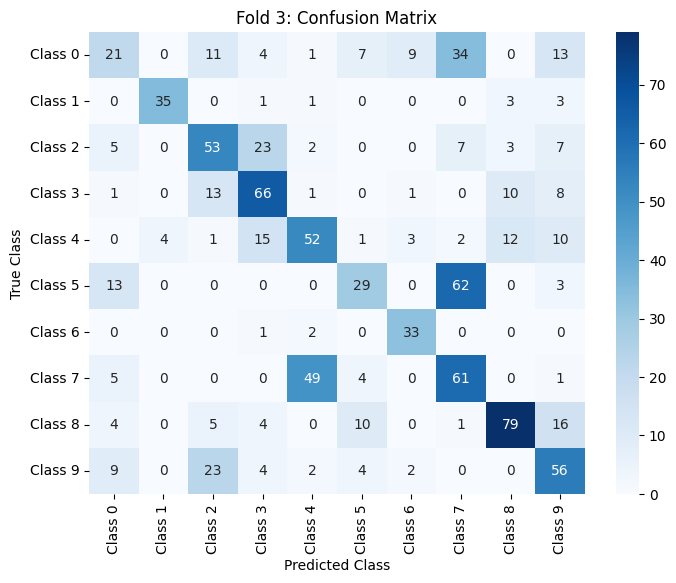

Fold 3: Loss = 1.4595, Accuracy = 0.5243
Epoch 1/30


C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0949 - loss: 2.7000 - val_accuracy: 0.1506 - val_loss: 2.3084
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1267 - loss: 2.4565 - val_accuracy: 0.2222 - val_loss: 2.2582
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1532 - loss: 2.3795 - val_accuracy: 0.2660 - val_loss: 2.2291
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1671 - loss: 2.3133 - val_accuracy: 0.3162 - val_loss: 2.1990
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1914 - loss: 2.2454 - val_accuracy: 0.3558 - val_loss: 2.1640
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2176 - loss: 2.2083 - val_accuracy: 0.3707 - val_loss: 2.1268
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2266 - loss: 2.1756 - val_accuracy: 0.3825 - val_loss: 2.0877
Epoch 8/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2539 - loss: 2.1304 - val_accuracy: 0.3996 - val_

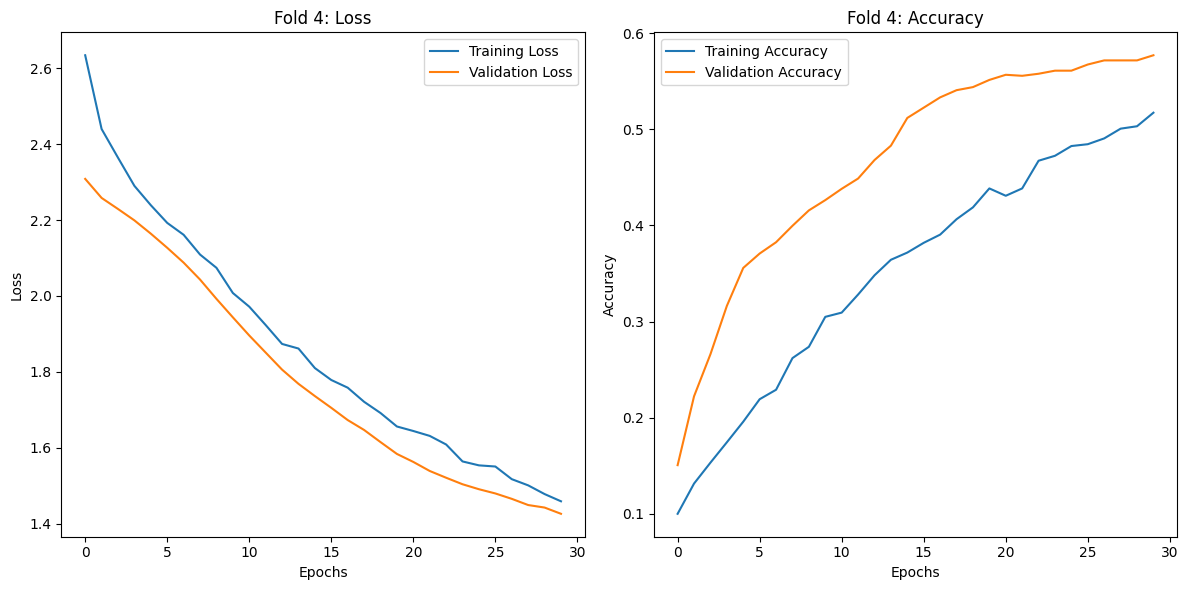

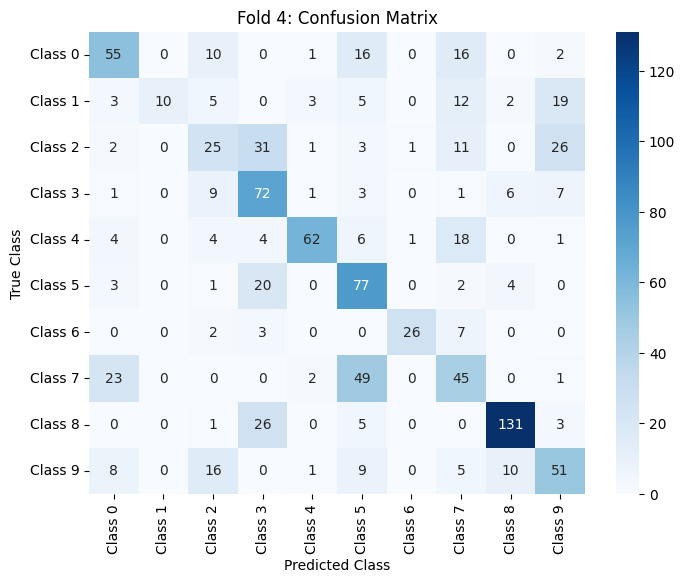

Fold 4: Loss = 1.4359, Accuracy = 0.5596
Epoch 1/30


C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1094 - loss: 2.6241 - val_accuracy: 0.1288 - val_loss: 2.2988
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1410 - loss: 2.4010 - val_accuracy: 0.2005 - val_loss: 2.2478
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1624 - loss: 2.3188 - val_accuracy: 0.2430 - val_loss: 2.2070
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1844 - loss: 2.2850 - val_accuracy: 0.2600 - val_loss: 2.1693
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1992 - loss: 2.2122 - val_accuracy: 0.2904 - val_loss: 2.1273
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2312 - loss: 2.1555 - val_accuracy: 0.3026 - val_loss: 2.0874
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2579 - loss: 2.1200 - val_accuracy: 0.3171 - val_loss: 2.0413
Epoch 8/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2690 - loss: 2.0615 - val_accuracy: 0.3232 - val_

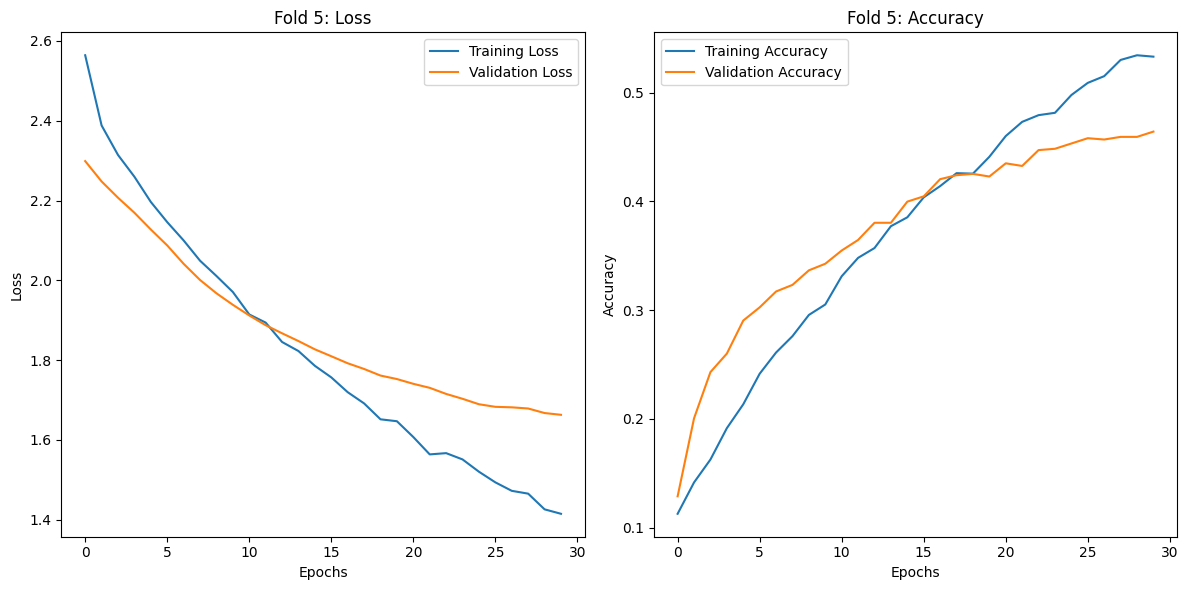

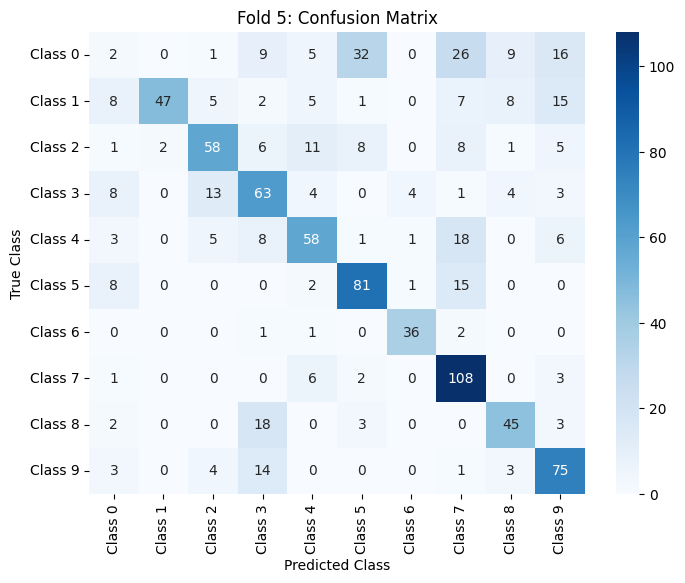

Fold 5: Loss = 1.4718, Accuracy = 0.6122
Epoch 1/30


C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1123 - loss: 2.6451 - val_accuracy: 0.1838 - val_loss: 2.2809
Epoch 2/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1399 - loss: 2.4232 - val_accuracy: 0.2458 - val_loss: 2.2266
Epoch 3/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1703 - loss: 2.3345 - val_accuracy: 0.2709 - val_loss: 2.1870
Epoch 4/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1811 - loss: 2.2961 - val_accuracy: 0.2995 - val_loss: 2.1502
Epoch 5/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2233 - loss: 2.2021 - val_accuracy: 0.3246 - val_loss: 2.1040
Epoch 6/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2322 - loss: 2.1788 - val_accuracy: 0.3449 - val_loss: 2.0593
Epoch 7/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2651 - loss: 2.1037 - val_accuracy: 0.3544 - val_loss: 2.0097
Epoch 8/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2886 - loss: 2.0372 - val_accuracy: 0.3604 - val_

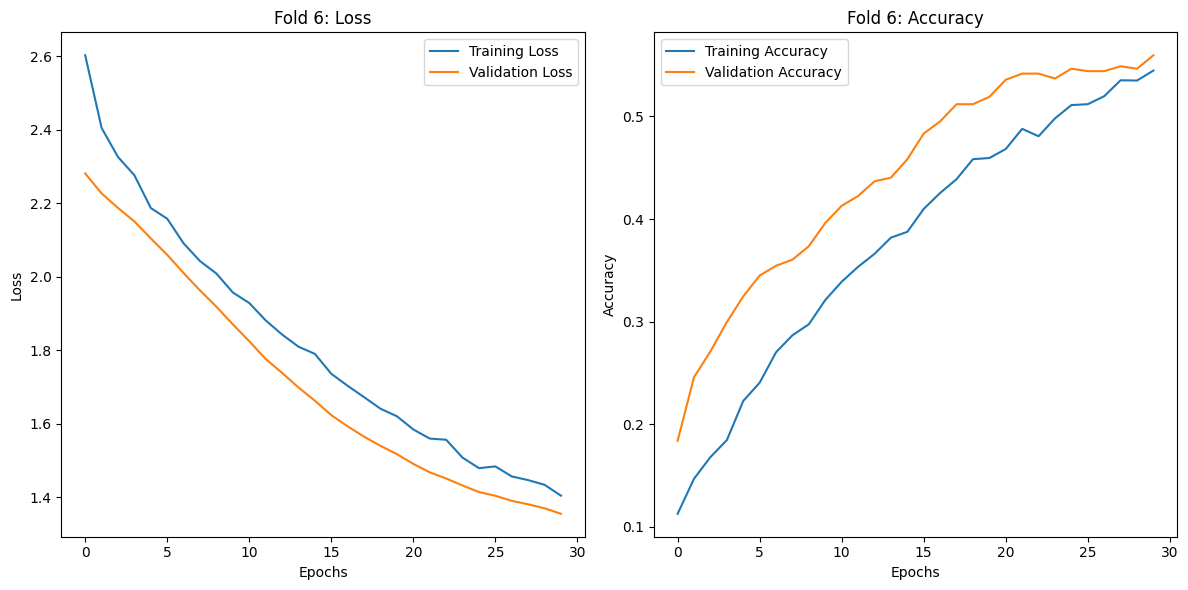

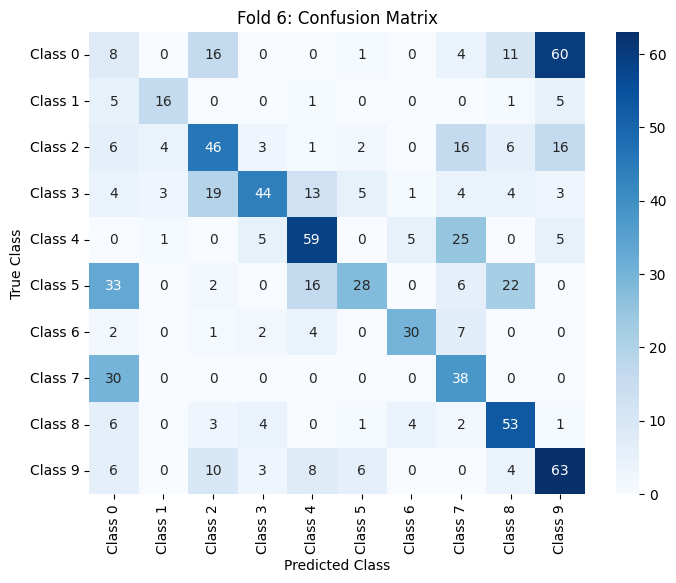

Fold 6: Loss = 1.6019, Accuracy = 0.4678


C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1034 - loss: 2.6606 - val_accuracy: 0.2618 - val_loss: 2.2458
Epoch 2/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1406 - loss: 2.4466 - val_accuracy: 0.3424 - val_loss: 2.1966
Epoch 3/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1617 - loss: 2.3497 - val_accuracy: 0.3598 - val_loss: 2.1500
Epoch 4/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1855 - loss: 2.2975 - val_accuracy: 0.3610 - val_loss: 2.1032
Epoch 5/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2204 - loss: 2.1966 - val_accuracy: 0.4243 - val_loss: 2.0526
Epoch 6/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2389 - loss: 2.1560 - val_accuracy: 0.4429 - val_loss: 1.9987
Epoch 7/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2670 - loss: 2.1130 - val_accuracy: 0.4665 - val_loss: 1.9371
Epoch 8/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2857 - loss: 2.0631 - val_accuracy: 0.

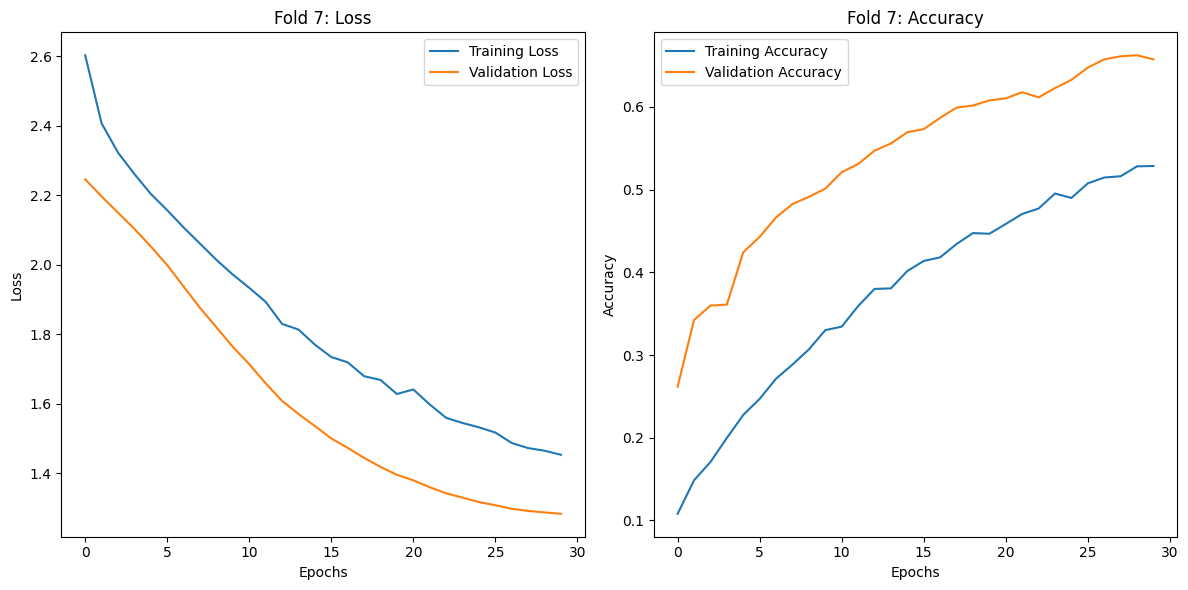

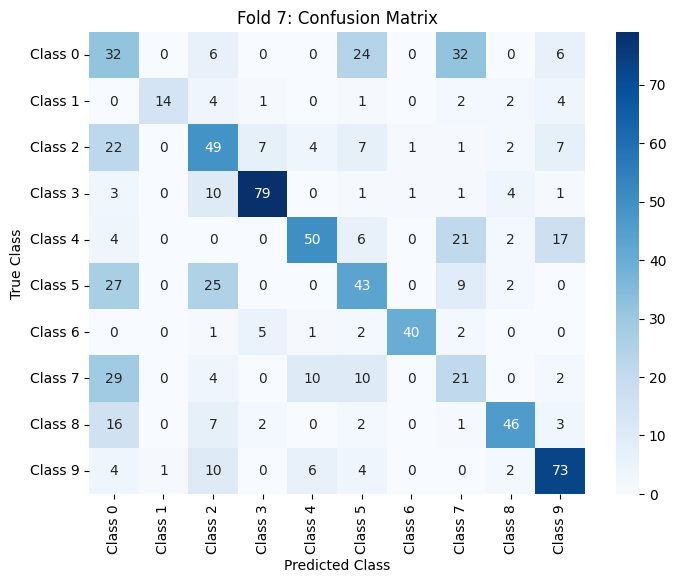

Fold 7: Loss = 1.3497, Accuracy = 0.5334
Epoch 1/30


C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1122 - loss: 2.6306 - val_accuracy: 0.2022 - val_loss: 2.3061
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1218 - loss: 2.4480 - val_accuracy: 0.2414 - val_loss: 2.2395
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1466 - loss: 2.3530 - val_accuracy: 0.2904 - val_loss: 2.2002
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1739 - loss: 2.2852 - val_accuracy: 0.3027 - val_loss: 2.1634
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1908 - loss: 2.2619 - val_accuracy: 0.3333 - val_loss: 2.1164
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2151 - loss: 2.2169 - val_accuracy: 0.3431 - val_loss: 2.0565
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2376 - loss: 2.1497 - val_accuracy: 0.3652 - val_loss: 1.9971
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2568 - loss: 2.1213 - val_accuracy: 0.3787 - val_

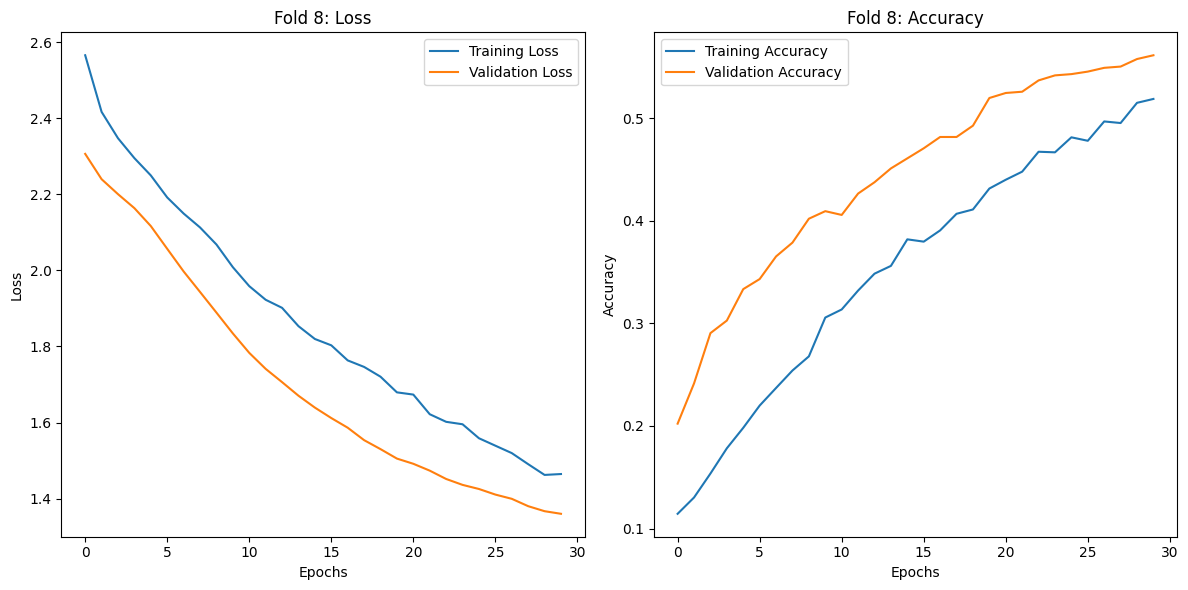

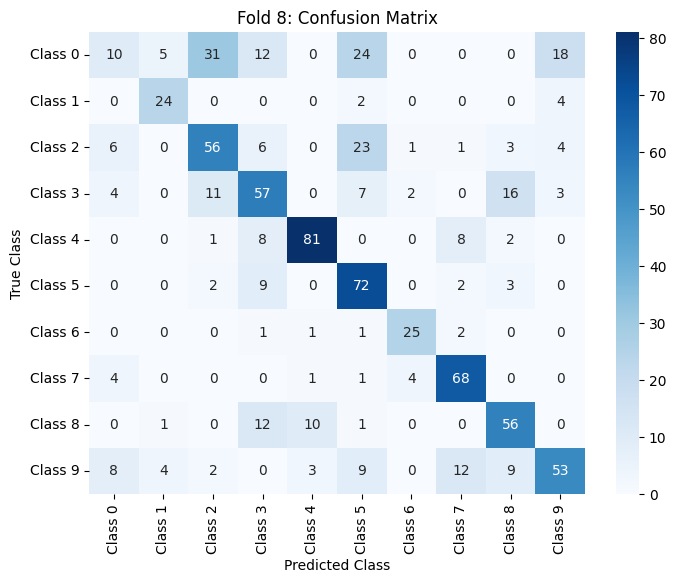

Fold 8: Loss = 1.3599, Accuracy = 0.6228
Epoch 1/30


C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1050 - loss: 2.6212 - val_accuracy: 0.2867 - val_loss: 2.2782
Epoch 2/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1397 - loss: 2.4357 - val_accuracy: 0.2975 - val_loss: 2.2310
Epoch 3/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1668 - loss: 2.3104 - val_accuracy: 0.3274 - val_loss: 2.1903
Epoch 4/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1730 - loss: 2.3247 - val_accuracy: 0.3644 - val_loss: 2.1512
Epoch 5/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1967 - loss: 2.2419 - val_accuracy: 0.3704 - val_loss: 2.1014
Epoch 6/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2297 - loss: 2.1834 - val_accuracy: 0.3955 - val_loss: 2.0405
Epoch 7/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2288 - loss: 2.1696 - val_accuracy: 0.4277 - val_loss: 1.9822
Epoch 8/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2565 - loss: 2.1037 - val_accuracy: 0.4289 - val_

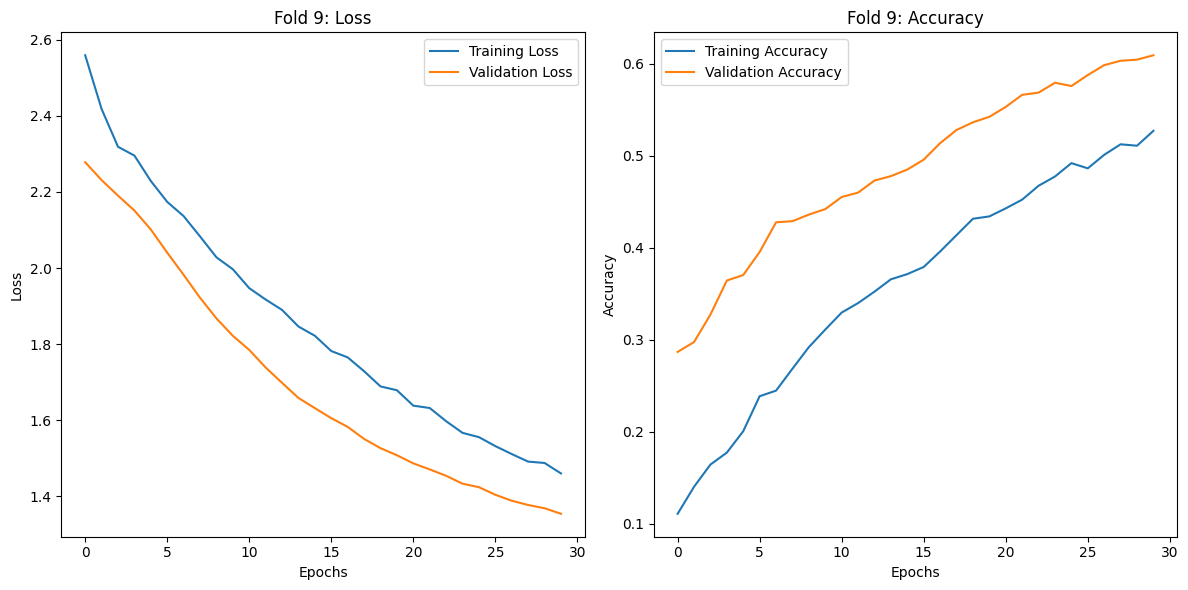

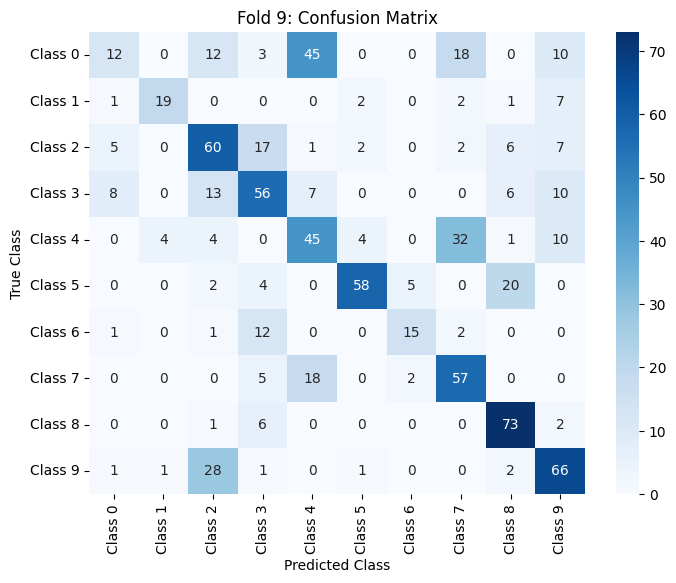

Fold 9: Loss = 1.3203, Accuracy = 0.5650


C:\Users\kikot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1174 - loss: 2.6081 - val_accuracy: 0.1397 - val_loss: 2.3089
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1345 - loss: 2.4331 - val_accuracy: 0.2348 - val_loss: 2.2676
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1710 - loss: 2.3397 - val_accuracy: 0.2806 - val_loss: 2.2316
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1799 - loss: 2.2890 - val_accuracy: 0.3104 - val_loss: 2.1933
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2017 - loss: 2.2268 - val_accuracy: 0.3310 - val_loss: 2.1466
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2285 - loss: 2.1774 - val_accuracy: 0.3505 - val_loss: 2.0973
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2486 - loss: 2.1245 - val_accuracy: 0.3666 - val_loss: 2.0421
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2781 - loss: 2.0902 - val_accuracy: 0

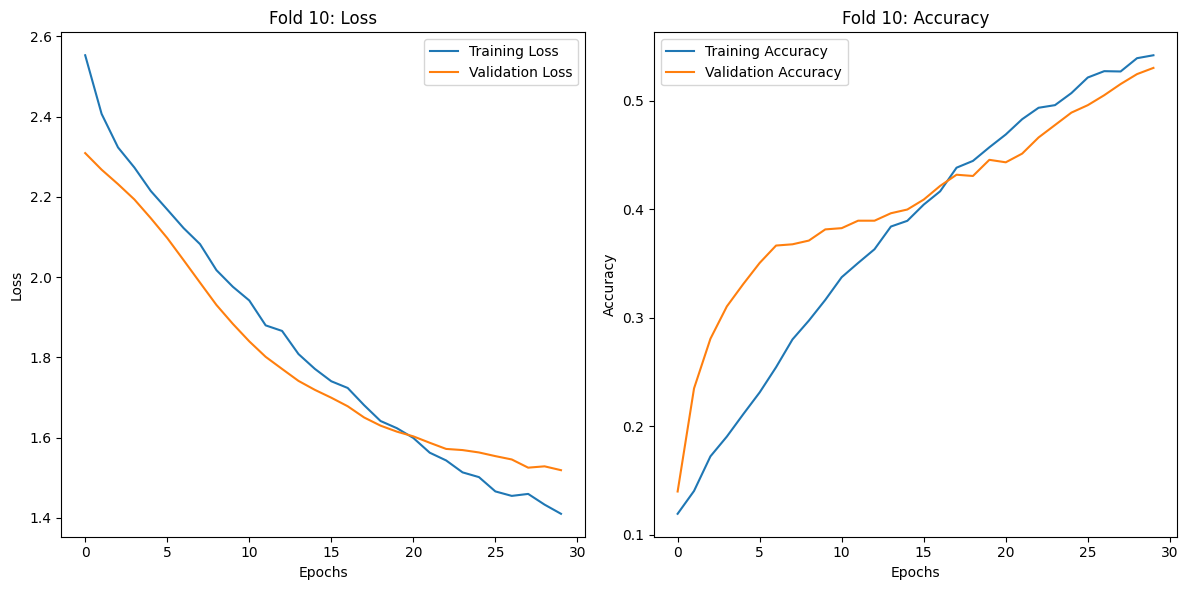

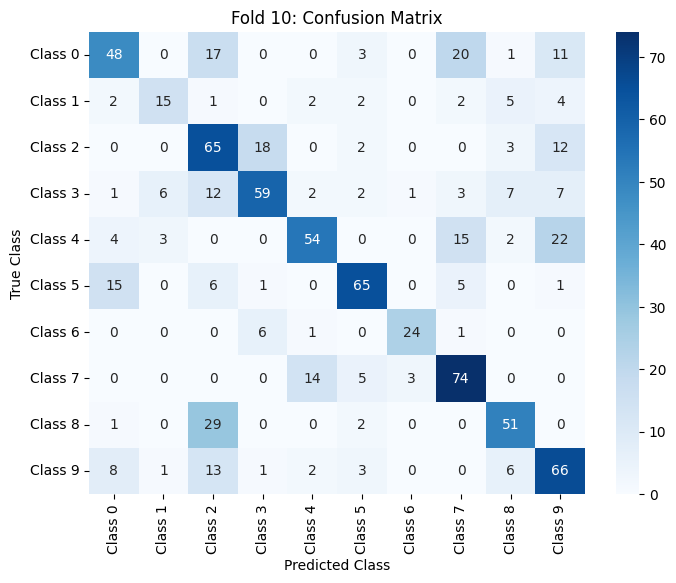

Fold 10: Loss = 1.3279, Accuracy = 0.6225

Resultados Finais:
Acurácia Média: 56.14%
Desvio Padrão da Acurácia: 4.70%


In [ ]:
epochs = 30
batch_size = 64

validation_folds = {1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 1}

cumulative_conf_matrix = np.zeros((num_classes, num_classes), dtype=int)
fold_accuracies = []
fold_losses = []

for test_fold in unique_folds:

    val_fold = validation_folds[test_fold]
    
    if test_fold == val_fold:
        continue

    X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, test_fold, val_fold)

    model = create_model(l2_value=0.0001)

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),
                        callbacks=[early_stopping],
                        verbose=1)

    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    fold_accuracies.append(test_accuracy)
    fold_losses.append(test_loss)

    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    fold_conf_matrix = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    cumulative_conf_matrix += fold_conf_matrix

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Fold {test_fold}: Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Fold {test_fold}: Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(fold_conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=[f"Class {i}" for i in range(num_classes)],
                yticklabels=[f"Class {i}" for i in range(num_classes)])
    plt.title(f'Fold {test_fold}: Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

    print(f"Fold {test_fold}: Loss = {test_loss:.4f}, Accuracy = {test_accuracy:.4f}")

### Matrix de Confusão Cumulativa


Resultados Finais:
Acurácia Média: 56.14%
Desvio Padrão: 4.70%


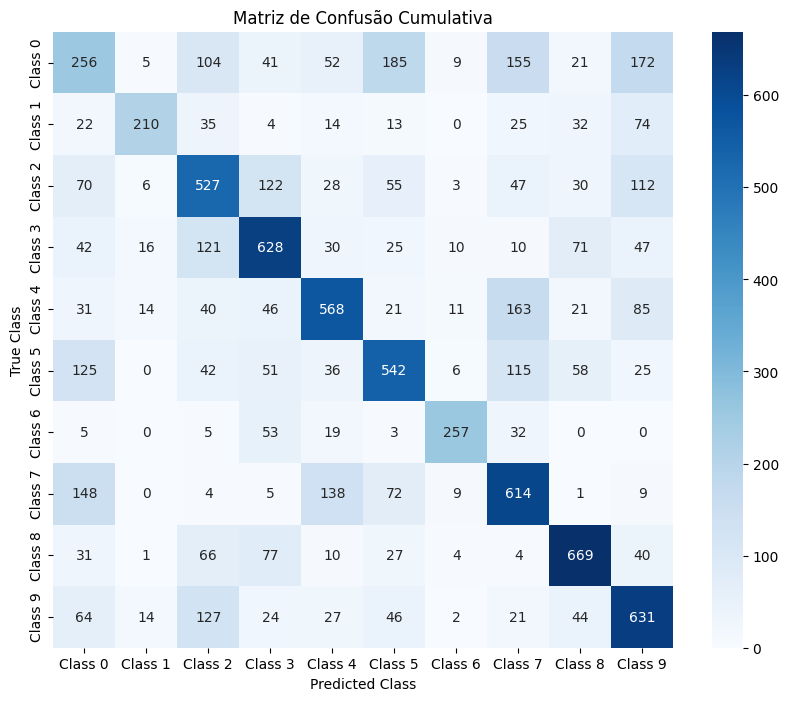

In [ ]:
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"\nResultados Finais:")
print(f"Acurácia Média: {mean_accuracy * 100:.2f}%")
print(f"Desvio Padrão: {std_accuracy * 100:.2f}%")

plt.figure(figsize=(10, 8))
class_labels = [f"Class {i}" for i in range(num_classes)]
sns.heatmap(cumulative_conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_labels, yticklabels=class_labels)

plt.title("Matriz de Confusão Cumulativa")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()




#### Resultados MLP

Os resultados indicam que o modelo MLP alcançou uma precisão de treino superior à precisão de validação, especialmente nas últimas épocas. Isso sugere um possível sobreajuste, onde o modelo aprendeu a capturar ruídos ou padrões específicos do conjunto de treino que não generalizam bem para os dados de validação

A regularização L2 e o Dropout foram testados com diferentes valores. Verificou-se que valores de L2 muito baixos resultaram em menor controle sobre o sobreajuste, enquanto valores muito altos limitaram a capacidade do modelo de aprender. O Dropout de 50% apresentou um bom equilíbrio ao reduzir o risco de sobreajuste sem comprometer o desempenho do modelo.

Analisando a matriz de confusão podemos ver que a classe que obteve mais exemplos corretamente classificados foi a Class 8 seguida da Class 9. As classes com menor número foram a Class 0, a Class 1 e a Class 6. Este comportamento poderá explicar-se devido ao desbalanceamento destas duas últimas classes.

Apesar de os resultados atingiram um nível bom, é possível que características mais avançadas ou o uso de redes mais complexas, como CNNs, possam melhorar os resultados ao capturar melhor as relações temporais e espectrais dos áudios.

Em resumo, o modelo MLP é uma abordagem válida para a classificação dos sons urbanos, mas apresenta limitações que podem ser superadas com arquiteturas mais avançadas. Esse estudo estabelece uma base sólida para explorações futuras e demonstra a eficácia de métodos simples no aprendizado de padrões sonoros.

## Implementação do CNN

In [4]:
metadata_path = r"C:\Users\admin\Desktop\AC II\UrbanSound8K\metadata\UrbanSound8K.csv"
metadata = pd.read_csv(metadata_path)
print(metadata.head())

      slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  


In [ ]:
'''
# Parâmetros
SAMPLE_RATE = 22050
DURATION = 4  # em segundos
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

# Caminho para o dataset
input_path = r"C:\Users\admin\Desktop\AC II\UrbanSound8K\audio"
metadata_path = r"C:\Users\admin\Desktop\AC II\UrbanSound8K\metadata\UrbanSound8K.csv"
output_base_path = r"C:\Users\admin\Desktop\AC II\ProcessedAudio"

# Carregar o arquivo de metadados
metadata = pd.read_csv(metadata_path)

# Função para padronizar o áudio (padding ou repeat)
def preprocess_audio(file_path, method="padding", sample_rate=SAMPLE_RATE, duration=DURATION):
    try:
        # Carregar o áudio
        signal, sr = librosa.load(file_path, sr=sample_rate)
        target_length = sample_rate * duration

        # Ajustar o tamanho do sinal
        if len(signal) < target_length:
            if method == "padding":
                # Adicionar zeros
                signal = np.pad(signal, (0, target_length - len(signal)), 'constant')
            elif method == "repeat":
                # Repetir o som
                repeat_count = target_length // len(signal) + 1
                signal = np.tile(signal, repeat_count)[:target_length]
        else:
            # Truncar o sinal longo
            signal = signal[:target_length]

        return signal
    except Exception as e:
        print(f"Erro ao processar {file_path}: {e}")
        return None

# Criar as pastas de saída (padding e repeat)
os.makedirs(os.path.join(output_base_path, "padding"), exist_ok=True)
os.makedirs(os.path.join(output_base_path, "repeat"), exist_ok=True)

for folder in range(1, 11):  # UrbanSound8K possui folders de 1 a 10
    os.makedirs(os.path.join(output_base_path, "padding", f"fold{folder}"), exist_ok=True)
    os.makedirs(os.path.join(output_base_path, "repeat", f"fold{folder}"), exist_ok=True)

# Adicionar o caminho completo dos arquivos ao dataframe
metadata['file_path'] = metadata.apply(
    lambda row: os.path.join(input_path, f"fold{row['fold']}", row['slice_file_name']), axis=1
)

# Processar e salvar os áudios
for index, row in metadata.iterrows():
    file_path = row['file_path']
    fold = row['fold']
    file_name = row['slice_file_name']
    
    # Processar com padding
    signal_padding = preprocess_audio(file_path, method="padding")
    if signal_padding is not None:
        output_folder_padding = os.path.join(output_base_path, "padding", f"fold{fold}")
        np.save(os.path.join(output_folder_padding, file_name.replace('.wav', '.npy')), signal_padding)

    # Processar com repeat
    signal_repeat = preprocess_audio(file_path, method="repeat")
    if signal_repeat is not None:
        output_folder_repeat = os.path.join(output_base_path, "repeat", f"fold{fold}")
        np.save(os.path.join(output_folder_repeat, file_name.replace('.wav', '.npy')), signal_repeat)

print("Processamento concluído e dados salvos!")
'''

## Extração de features

Após o pré-processamento, iremos avançar para a extração das features, espectogramas e MFCC. Para os espectogramas foram usados 128 mels e para o mfcc foram usados 40 coeficientes. Estes valores foram baseados em estudos deste mesmo trabalho.

In [ ]:
def extract_mel_spectrogram(signal, sample_rate=22050, n_mels=128):
    """
    Extrai o espectrograma de Mel do sinal de áudio.
    """
    S = librosa.feature.melspectrogram(y=signal, sr=sample_rate, n_mels=n_mels)
    return librosa.power_to_db(S).T  # Converte para dB e transpõe

# Ainda nao extrai o espetograma, mas é util para o CNN 2D. Para isso basta substituir la em baixo a funçao e tambem os arquivos

def extract_mfcc(signal, sample_rate=22050, n_mfcc=40):
    """
    Extrai os MFCCs do sinal de áudio.
    """
    mfccs = librosa.feature.mfcc(y=signal, sr=sample_rate, n_mfcc=n_mfcc)
    return mfccs.T  # Transpor para ter (tempo x coeficientes)

# Caminho para os sinais processados (ex.: padding)
processed_data_path = r"C:\Users\admin\Desktop\AC II\ProcessedAudio\repeat"

# Caminho para salvar os MFCCs
output_mfcc_path = r"C:\Users\admin\Desktop\AC II\Spectrogram\repeat"
os.makedirs(output_mfcc_path, exist_ok=True)

# Loop pelos folds
for fold in range(1, 11):
    input_folder = os.path.join(processed_data_path, f"fold{fold}")
    output_folder = os.path.join(output_mfcc_path, f"fold{fold}")
    os.makedirs(output_folder, exist_ok=True)

    for file in os.listdir(input_folder):
        if file.endswith(".npy"):
            # Carregar o sinal
            signal = np.load(os.path.join(input_folder, file))
            
            # Extrair MFCCs
            mfcc = extract_mel_spectrogram(signal)
            
            # Salvar os MFCCs como numpy array
            np.save(os.path.join(output_folder, file), mfcc)

print("Extração de MFCCs concluída!")

In [3]:
def load_spectrograms_by_fold(folder_path):
    """
    Carrega os spectrogramas organizados por fold.
    """
    X_folds = []
    y_folds = []

    # Carregar os spectrogramas e organizar por fold
    for fold in range(1, 11):  # UrbanSound8K tem 10 folds
        fold_path = os.path.join(folder_path, f"fold{fold}")
        X_fold = []
        y_fold = []

        for file in os.listdir(fold_path):
            if file.endswith(".npy"):
                # Carregar o spectrograma
                spectrogram = np.load(os.path.join(fold_path, file))

                # Adicionar um canal extra para o formato 2D
                spectrogram = np.expand_dims(spectrogram, axis=-1)
                X_fold.append(spectrogram)

                # Associar o rótulo
                label = int(file.split("-")[1])  # Exemplo: "7061-6-0-0.npy" -> classe 6
                y_fold.append(label)

        X_folds.append(np.array(X_fold))
        y_folds.append(np.array(y_fold))

    # Calcular a média e o desvio padrão globais (após carregar os dados)
    all_spectrograms = np.concatenate([fold for fold in X_folds], axis=0)  # Combina todos os folds
    global_mean = np.mean(all_spectrograms)
    global_std = np.std(all_spectrograms)

    # Padronizar cada spectrograma com a média e desvio padrão globais
    for fold_idx in range(len(X_folds)):
        X_folds[fold_idx] = (X_folds[fold_idx] - global_mean) / global_std

    return X_folds, y_folds

# Caminho para os spectrogramas
spectrogram_folder_path = r"C:\Users\admin\Desktop\AC II\Spectrogram\padding"
X_folds, y_folds = load_spectrograms_by_fold(spectrogram_folder_path)

print(f"Número de folds: {len(X_folds)}")
print(f"Tamanho do Fold 1: {X_folds[0].shape}, {y_folds[0].shape}")


Número de folds: 10
Tamanho do Fold 1: (873, 173, 128, 1), (873,)


## Arquitetura da rede

A nossa arquitetura pode ser representada pela imagem abaixo.

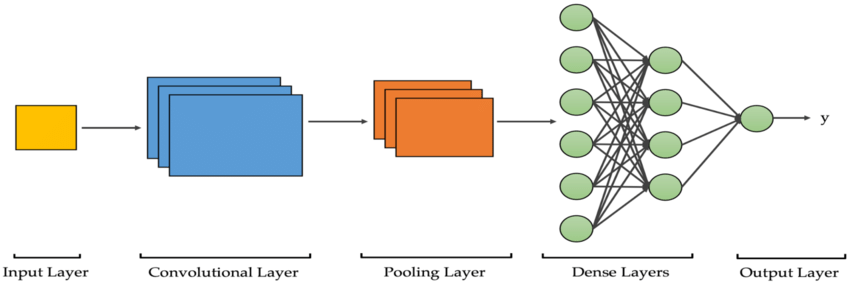![image.png](attachment:5912f349-c94c-47d3-9c98-2dbafd411883.png)

Tal como na imagem, a nossa rede começa por uma camada de input que é responsável por definir o formato dos dados de input. No nosso caso, os dados são espectrogramas com dimensões (173, 128, 1), onde estes números representam a altura, a largura e o 1 significa que o áudio é mono.

A rede contém 3 camadas convolucionais, cada uma seguida por uma opração de pooling e dropout. Cada uma destas camadas tem a funçao ReLU como função de ativação, um Kernel Size de (3,3) e a l2 regularization que através da aplicação de pesos ajuda a prevenir o overfitting. (Esta escolha foi baseado no trabalho [https://github.com/HassanMahmoodKhan/Urban-Sound-Classification-using-Convolutional-Neural-Networks]). Em termos de filtros:
- Primeira camada: 32 filtros 
- Segunda camada: 64 filtros 
- Terceira camada: 128 filtros.

Cada uma destas camadas, como referido em cima, são seguidas de pooling e dropout, onde para o pooling foi usado o MaxPooling (2,2) (também baseado no trabalho [https://github.com/HassanMahmoodKhan/Urban-Sound-Classification-using-Convolutional-Neural-Networks]) e para o dropout foi usado um dropout rate de 0.4 (testado neste trabalho).

Temos também uma camada de Flatten onde é feita a transformação dos feature maps 2D em um vetor 1D para depois estes serem usadas na nossa Dense Layers onde apresentam 256 neurónios cada um com a função de ativação ReLU, com L2 Regularization e com Dropout de 0.4. 

Por fim o Output Layer com 10 unidades (que representam cada classe do nosso problema) com a função de ativação SoftMax para obter as probabilidades de cada classe e a L2 Regularization. Como otimizador foram testados o Adam, o SGD e RMSProp onde o que se provou mais eficiente foi o Adam.

In [20]:
def train_cnn_2d(
    X_train, y_train, X_val, y_val, X_test, y_test,
    input_shape=(173, 128, 1),
    filters=[32, 64, 128],
    kernel_size=(3, 3),
    pool_size=(2, 2),
    dropout_rate=0.3,
    dense_units=256,
    optimizer='adam',
    learning_rate=0.001,
    epochs=10,
    batch_size=32,
    l2_lambda=0.001
):

    # Limpar sessão para evitar acumulação de estado
    K.clear_session()

    # Mapear otimizadores
    optimizers = {
        'adam': Adam(learning_rate=learning_rate),
        'rmsprop': RMSprop(learning_rate=learning_rate),
        'sgd': SGD(learning_rate=learning_rate, momentum=0.9)
    }
    opt = optimizers.get(optimizer.lower(), Adam(learning_rate=learning_rate))
    
    # Construir o modelo
    model = Sequential()
    for i, f in enumerate(filters):
        if i == 0:
            model.add(Conv2D(f, kernel_size, activation='relu', padding='same', input_shape=input_shape,
                             kernel_regularizer=l2(l2_lambda)))  # Adiciona L2 na primeira camada
        else:
            model.add(Conv2D(f, kernel_size, activation='relu', padding='same', 
                             kernel_regularizer=l2(l2_lambda)))  # Adiciona L2 nas camadas subsequentes
        model.add(MaxPooling2D(pool_size))
        model.add(Dropout(dropout_rate))
    
    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_lambda)))  # Adiciona L2 na camada densa
    model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax', kernel_regularizer=l2(l2_lambda)))  # Adiciona L2 na camada de saída

    # Compilar o modelo
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    # Configurar callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    checkpoint = ModelCheckpoint(
        filepath=f"model_fold_checkpoint.keras",
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    )
    
    # Configurar o gerador com augmentação
    datagen = ImageDataGenerator(
        width_shift_range=0.1,  # Deslocar horizontalmente
        height_shift_range=0.1,  # Deslocar verticalmente
        zoom_range=0.2,  # Zoom aleatório
        horizontal_flip=True  # Inverter horizontalmente
    )
    
    # Ajustar o gerador com os dados de treino
    datagen.fit(X_train)

    # Usar o gerador no treinamento
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=batch_size),
        validation_data=(X_val, y_val),
        epochs=epochs,
        callbacks=[early_stopping, checkpoint],
        verbose=1
    )

    # Avaliar no conjunto de teste
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    return model, history, test_loss, test_accuracy


## Hiperparâmetros Utilizados

Iremos falar um pouco dos valores usados, onde os resultados estarão presentes mais a abaixo.

1. Learning Rate- Está responsável por controlar o tamanho do passo que o otimizador dá ao ajustar os pesos da rede. Foram testados os valores, 0.01, 0.0001 e 0.001 onde o último valor mostrou-se melhor, proporcionando um equilíbrio entre a convergência rápida e estabilidade no treino.
    
2. Dropout Rate- Após a observação dos gráficos da evolução do loss no treino e na validação concluimos que a diferença entre estes era relativamente grande o que pode mostrar a existência de overfitting. De forma a combater, testamos um dropout rate de 0.3 e 0.4 onde 0.4 se mostrou mais eficaz. Não testamos para 0.5 pois também queríamos aplicar um Weight Regularization.

3. L2 Regularization- Como dito anteriormente, foi aplicado o L2 Regularization. Após testes realizados com valores de 0.001 e 0.01, o valor 0.001 mostrou-se melhor. Este método é utilizado para penalizar pesos muito grandes, generalizando melhor para dados novos.

4. Otimizador- O Adam foi o otimizador escolhido após testes realizados com outras opções, como SGD e RMSProp. O otimizador Adam combina as vantagens do RMSProp e do SGD com momentum, ajustando dinamicamente o learning rate de cada parâmetro e mostrando-se consistente e eficiente para este problema. Foi ainda testado um Learning Rate Decay nos otimizadores mas os otimizadores não se mostraram bons o suficiente para serem superiores ao Adam sem Decay.

5. Batch Size- Foi definido um valor de 32 que ajuda a equilibrar o custo computacional com a necessidade de estabilidade no cálculo dos gradientes. Este valor foi baseado no estudo.

6. Número de Epochs- O número máximo de epochs foi definido como 40. Porém, devido ao uso do early stopping, o treinamento era interrompido quando o desempenho na validation deixava de melhorar por 3 epochs consecutivas, evitando assim treinos desnecessários.

7. Filtros, Kernel Size, Pooling- Já foram discutidas no tópico da arquitetura da rede, mas estes três valores não foram alterados e os valores usados foram baseados no estudo.


In [ ]:
l2_lambda = 0.001  # Ajuste conforme necessário

# Número de classes (UrbanSound8K tem 10 classes)
num_classes = 10

# Converter rótulos para one-hot encoding
y_folds_one_hot = [to_categorical(y, num_classes=num_classes) for y in y_folds]

# Relação fixa entre folds de teste e validação (exemplo arbitrário)
validation_folds = {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 0}

# Lista de otimizadores a testar
optimizer_to_test = 'adam'

# Fixar os melhores hiperparâmetros encontrados
dropout_rate = 0.4
learning_rate = 0.001

# Caminho para salvar os resultados
output_path = "Resultados_finais_spectogramas_confusao.txt"

# Inicializar matriz de confusão acumulativa
cumulative_conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

# Criar ou limpar o arquivo de resultados
with open(output_path, "w") as file:
    file.write("Resultados dos Testes\n")
    file.write("=====================\n\n")
    
    fold_accuracies = []
    fold_losses = []

    # Loop por folds
    for test_fold_idx in range(10):  # Testar em cada fold
        val_fold_idx = validation_folds[test_fold_idx]

        # Dividir os dados
        X_test = X_folds[test_fold_idx]
        y_test = y_folds_one_hot[test_fold_idx]
        X_val = X_folds[val_fold_idx]
        y_val = y_folds_one_hot[val_fold_idx]
        X_train = np.concatenate([X_folds[i] for i in range(10) if i != test_fold_idx and i != val_fold_idx], axis=0)
        y_train = np.concatenate([y_folds_one_hot[i] for i in range(10) if i != test_fold_idx and i != val_fold_idx], axis=0)

        # Treinar a CNN
        model, history, test_loss, test_accuracy = train_cnn_2d(
            X_train, y_train, X_val, y_val, X_test, y_test,
            input_shape=(173, 128, 1),
            dropout_rate=dropout_rate,
            learning_rate=learning_rate,
            epochs=40,  # Ajustar conforme o tempo disponível
            batch_size=32,
            optimizer=optimizer_to_test,
            l2_lambda=l2_lambda
        )

        # Fazer previsões no conjunto de teste
        y_pred = model.predict(X_test)
        y_pred_classes = np.argmax(y_pred, axis=1)  # Classes previstas
        y_test_classes = np.argmax(y_test, axis=1)  # Classes verdadeiras
    
        # Atualizar a matriz de confusão acumulativa
        fold_conf_matrix = confusion_matrix(y_test_classes, y_pred_classes, labels=range(num_classes))
        cumulative_conf_matrix += fold_conf_matrix
        
        # Guardar os resultados do fold
        fold_accuracies.append(test_accuracy)
        fold_losses.append(test_loss)

        
        # # Salvar gráficos
        # plt.figure(figsize=(10, 6))
        # plt.plot(history.history['loss'], label='Train Loss')
        # plt.plot(history.history['val_loss'], label='Test Loss')
        # plt.title(f'Test Loss no fold {test_fold_idx + 1}')
        # plt.xlabel('Epoch')
        # plt.ylabel('Loss')
        # plt.legend()
        # plt.grid()
        # plt.savefig(f"Test_loss_fold_{test_fold_idx + 1}.png")
        # plt.close()

        # plt.figure(figsize=(10, 6))
        # plt.plot(history.history['accuracy'], label='Train accuracy')
        # plt.plot(history.history['val_accuracy'], label='Test accuracy')
        # plt.title(f'Test accuracy no fold {test_fold_idx + 1}')
        # plt.xlabel('Epochs')
        # plt.ylabel('Accuracy')
        # plt.legend()
        # plt.grid()
        # plt.savefig(f"Test accuracy no fold {test_fold_idx + 1}.png")
        # plt.close()
        
        # Escrever resultados do fold em tempo real
        with open(output_path, "a") as file:
            file.write(f"Fold {test_fold_idx + 1} - Test Accuracy: {test_accuracy * 100:.2f}%, Test Loss: {test_loss:.4f}\n")

    # Calcular resultados gerais
    mean_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)

    # Plotar a matriz de confusão cumulativa
    plt.figure(figsize=(10, 8))
    sns.heatmap(cumulative_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title("Cumulative Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.savefig("Cumulative_Confusion_Matrix.png")
    plt.close()

    # Escrever resultados gerais no arquivo
    with open(output_path, "a") as file:
       file.write("\nCumulative Confusion Matrix:\n")
       file.write(np.array2string(cumulative_conf_matrix, separator=", "))
       file.write(f"\n\nMean Accuracy: {mean_accuracy * 100:.2f}%\n")
       file.write(f"STD Accuracy: {std_accuracy * 100:.2f}%\n")
       file.write("=" * 30 + "\n")
    
    print(f"Resultados guardados em {output_path}")



## Justificação dos resultados obtidos com Espectograma

De forma a melhorar o nosso modelo e consequentemente os resultados obtidos, iremos fazer um "tuning" dos nossos hiperparâmetros.

Numa primeira fase implementamos o early stopping (para pouparmos recursos) com epochs de 20 e um dropout para diminuir o overfitting (alterando entre 0.3 e 0.4). Alteramos também o learning rate, variando entre 0.01, 0.001 e 0.0001 obtendo o melhor resultado para 0.001. 

    Testando Dropout: 0.3, Learning Rate: 0.01
    Fold 1 - Val Accuracy: 52.57%, Val Loss: 1.4295

    Testando Dropout: 0.3, Learning Rate: 0.001
    Fold 1 - Val Accuracy: 60.10%, Val Loss: 1.1851

    Testando Dropout: 0.3, Learning Rate: 0.0001
    Fold 1 - Val Accuracy: 61.76%, Val Loss: 1.1234

    Testando Dropout: 0.4, Learning Rate: 0.01
    Fold 1 - Val Accuracy: 11.95%, Val Loss: 2.2453

    Testando Dropout: 0.4, Learning Rate: 0.001
    Fold 1 - Val Accuracy: 62.48%, Val Loss: 0.9947

    Testando Dropout: 0.4, Learning Rate: 0.0001
    Fold 1 - Val Accuracy: 60.12%, Val Loss: 1.1234

Numa segunda análise decidimos experimentar diferentes otimizadores (Adam, SGD e RMSProp). Observamos que o RMSProp se comportava pior que os restantes por isso descartamos para os restantes testes. 
De forma a melhorar ainda mais, implementamos um decay no learning rate onde observamos uma subida no otimizador Adam e uma descida no SGD. Analisando os gráficos observamos que o val_loss ainda era bastante superior ao train_loss por isso decidimos adotar o L2 Regularization.

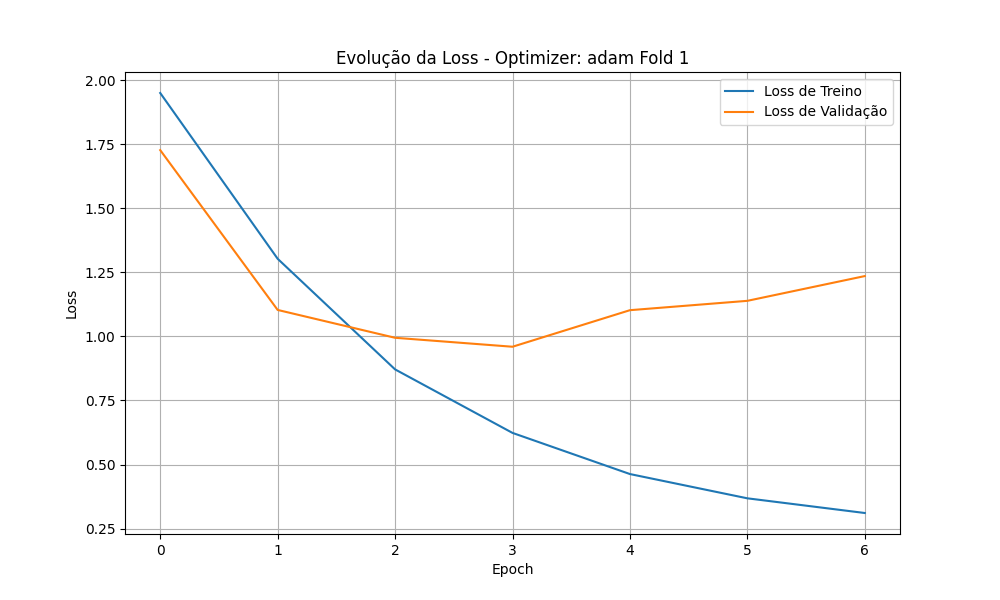

Como houve descidas nos valores da accuracy obtidas, variamos o valor escolhido para o lambda mas os resultados pioraram ainda mais.


Numa última análise decidimos implementar apenas o peso sem o decay onde vimos algumas melhorias. Por fim, como observamos que o overfitting poderia estar presente fizemos data augmentation onde a accuracy subiu para o melhor até ao momento. Como o data augmentation introduz ruído decidimos também reduzir o learning rate para 0.0005, aumentamos o epochs para 40 e a tolerância do early stopping para 5. Desta forma o modelo tem mais margem para aprender.

    Fold 1 - Val Accuracy: 63.63%, Val Loss: 1.2508

E o gráfico resultante foi

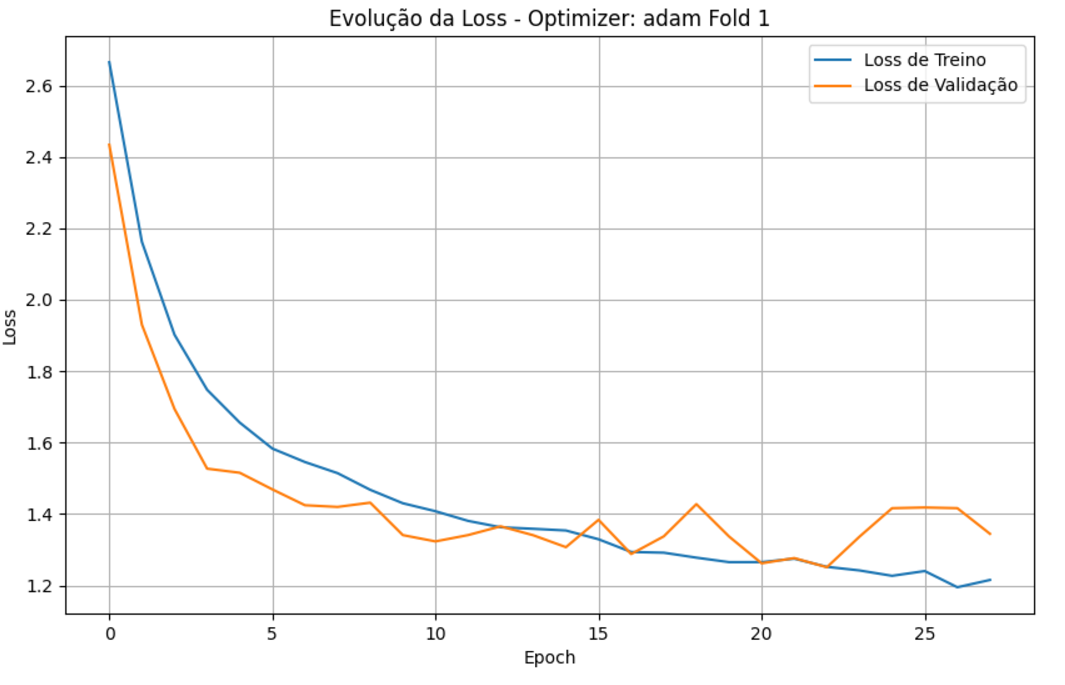


Concluímos assim a nossa estratégia de treinamento onde acreditamos ter chegado a um modelo consistente e robusto para este problema.

Vamos agora observar os dados obtidos para todas as 10 iterações do cross validation bem como a matriz de confusão

    Fold 1 - Test Accuracy: 62.43%, Test Loss: 1.3493
    Fold 2 - Test Accuracy: 52.93%, Test Loss: 1.3628
    Fold 3 - Test Accuracy: 60.11%, Test Loss: 1.2728
    Fold 4 - Test Accuracy: 61.11%, Test Loss: 1.3510
    Fold 5 - Test Accuracy: 44.55%, Test Loss: 1.5045
    Fold 6 - Test Accuracy: 65.37%, Test Loss: 1.2245
    Fold 7 - Test Accuracy: 45.58%, Test Loss: 1.5884
    Fold 8 - Test Accuracy: 63.65%, Test Loss: 1.7616
    Fold 9 - Test Accuracy: 69.61%, Test Loss: 1.2206
    Fold 10 - Test Accuracy: 59.74%, Test Loss: 1.3696

    
    Mean Accuracy: 58.51%
    STD Accuracy: 7.85%

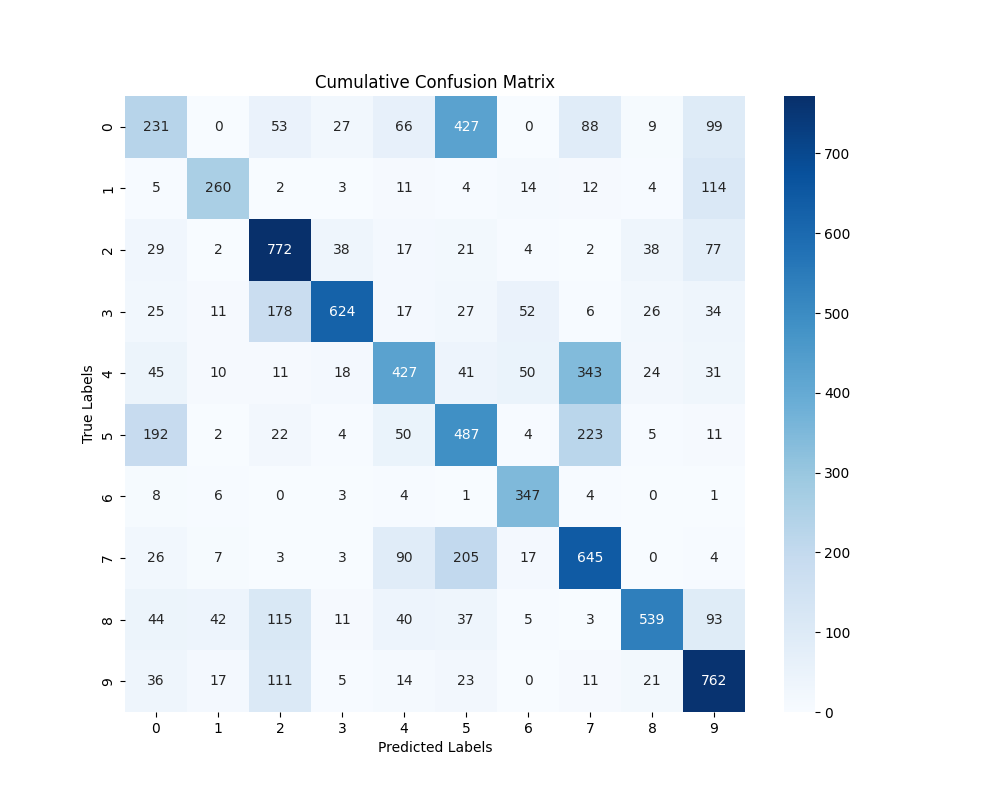


## Discussão dos resultados espectogramas

Podemos ver que os resultados obtidos foram bastante consistentes à exceção dos folders 5 e 7. Possivelmente estes folders apresentam resultados mais semelhantes e o modelo tem uma maior dificuldade em diferenciar os exemplos. Em relação à loss esta manteve-se bastante semelhante em todas as iterações.

Podemos ver ainda que a matriz de confusão nos diz que a class 4 (drilling) e a classe 5 (engine idling) estava a ser confundida com a class 7 (jackhammer) e que a classe 0 (air_conditioner) estava a ser confundida também com a classe 5 (engine idling), o que faz sentido porque no mundo real estes sons são bastantes semelhantes. Nesta matriz é possivel observar um elevado número de exemplos corretamente avaliados nas classes 2 e 9, e um número relativamente baixo nas classes 0 e 1.



## Justificação dos resultados obtidos com MFCC

Como sugerido pelo professor, o modelo CNN 2D pode receber também como entrada MFCC's. De forma a explorar um pouco a influência do input no modelo decidimos mudar o input para MFCC e de seguida observar se a diferença é ou não significativa.

Após uma primeira execução do código observamos que os gráficos apresentavam indícios de overfitting então decidimos aumentar o dropout. Como o modelo melhorou bastante, de forma a comparar com o Espectograma, rodamos as 10 iterações do cross validation e os resultados obtidos foram os seguintes

    Fold 1 - Test Accuracy: 60.43%, Test Loss: 1.5132
    Fold 2 - Test Accuracy: 62.16%, Test Loss: 1.4963
    Fold 3 - Test Accuracy: 51.14%, Test Loss: 1.7985
    Fold 4 - Test Accuracy: 60.00%, Test Loss: 1.5498
    Fold 5 - Test Accuracy: 64.96%, Test Loss: 1.4419
    Fold 6 - Test Accuracy: 57.84%, Test Loss: 1.7001
    Fold 7 - Test Accuracy: 66.47%, Test Loss: 1.3435
    Fold 8 - Test Accuracy: 56.45%, Test Loss: 1.8817
    Fold 9 - Test Accuracy: 63.24%, Test Loss: 1.4155
    Fold 10 - Test Accuracy: 66.07%, Test Loss: 1.3526


    Mean Accuracy: 60.43%
    STD Accuracy: 4.78%

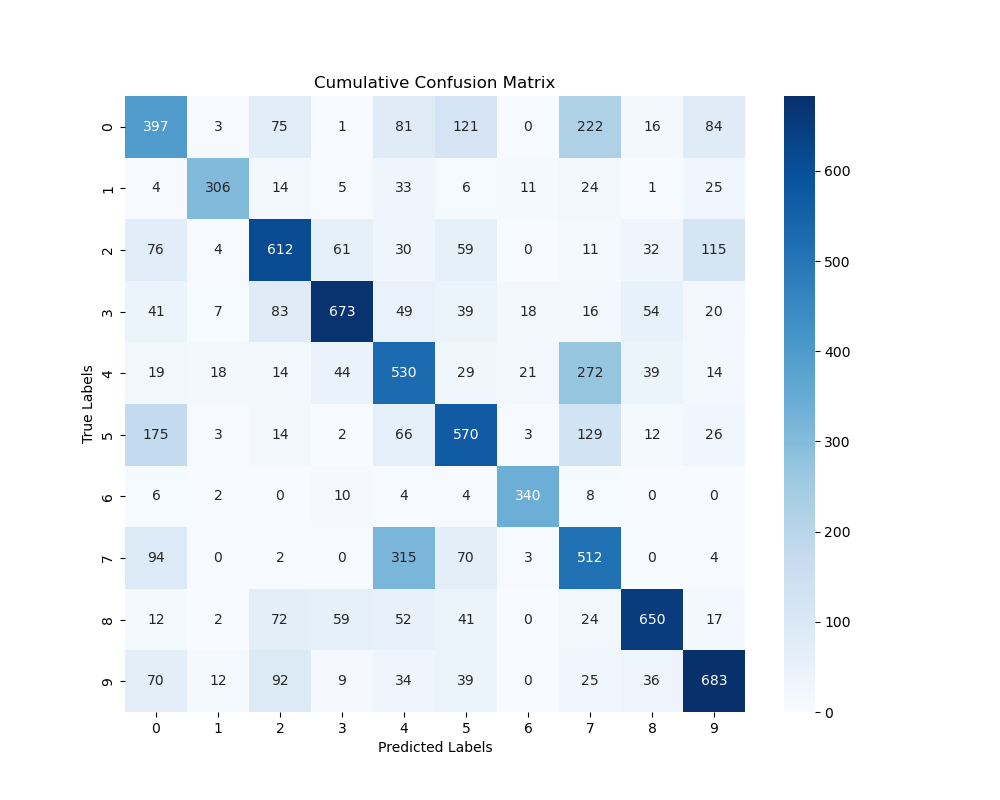


## Discussão dos resultados MFCC

Pelos resultados obtidos podemos ver um aumento na média da accuracy em relação ao Spectograms bem como uma diminuição no desvio padrão médio. Com o uso dos MFCC's vemos que já não há folders que se comportam de forma muito diferente dos restantes.

Em relação à matriz de confusão, a class que apresentou melhores resultados foi a class 9 seguida da classe 3. Podemos ver também, tal como nos Espectogramas, um grande número de exemplos confundidos entre a class 7 e a class 4 e vice-versa. Mais uma vez faz sentido neste contexto devia à parecença dos sons.

Iremos agora recorrer a testes estatísticos para ver se estas alterações são significativas.

## Testes estatísticos

### Espectogramas e MFCC's

In [4]:
spectrogram_accuracies = [62.43, 52.93, 60.11, 61.11, 44.55, 65.37, 45.58, 63.65, 69.61, 59.74]
mfcc_accuracies = [60.43, 62.16, 51.14, 60.00, 64.96, 57.84, 66.47, 56.45, 63.24, 66.07]

# Teste de normalidade
_, p_spectrogram = shapiro(spectrogram_accuracies)
_, p_mfcc = shapiro(mfcc_accuracies)

print(f"P-value Spectrogram: {p_spectrogram}")
print(f"P-value MFCC: {p_mfcc}")


P-value Spectrogram: 0.22266973555088043
P-value MFCC: 0.5716951489448547


In [5]:
# Teste t pareado
t_stat, p_value = ttest_rel(spectrogram_accuracies, mfcc_accuracies)
print(f"T-statistic: {t_stat}, P-value: {p_value}")


T-statistic: -0.6604562448529362, P-value: 0.525502715174967


In [6]:
spectrogram_losses = [1.3493, 1.3628, 1.2728, 1.3510, 1.5045, 1.2245, 1.5884, 1.7616, 1.2206, 1.3696]
mfcc_losses = [1.5132, 1.4963, 1.7985, 1.5498, 1.4419, 1.7001, 1.3435, 1.8817, 1.4155, 1.3526]

# Teste t pareado ou Wilcoxon para Loss
t_stat_loss, p_value_loss = ttest_rel(spectrogram_losses, mfcc_losses)
print(f"T-statistic (Loss): {t_stat_loss}, P-value (Loss): {p_value_loss}")

T-statistic (Loss): -2.033418334312038, P-value (Loss): 0.07253267869718898


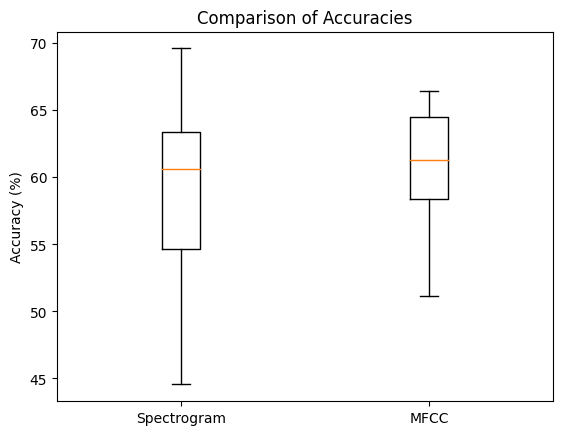

In [9]:
# Boxplot de acurácias
data = [spectrogram_accuracies, mfcc_accuracies]
labels = ['Spectrogram', 'MFCC']

plt.boxplot(data, labels=labels)
plt.title('Comparison of Accuracies')
plt.ylabel('Accuracy (%)')
plt.show()


## Discussão dos resultados ods testes estatísticos


Em relação ao uso de Spectograms ou de MFCC podemos concluir que, após os testes estatísticos, não há diferença significativa entre os métodos Spectrogram e MFCC em termos de accuracy (p > 0.05). Estas observações sugerem que ambos os métodos são viáveis, com vantagens potenciais específicas dependendo do cenário de aplicação.

## Conclusão

Neste trabalho, realizámos a análise de performance de uma Convolucional Neural Network (CNN) e de uma Multilayer Perceptron (MLP) aplicadas ao problema de classificação de áudio utilizando a base de dados UrbanSound8K. Foi feito um tuning manual para os dois modelos e no caso do CNN, foram exploradas duas abordagens distintas para representar os dados de input: espectrogramas e coeficientes MFCC. Após o tuning realizado no validation test, foi feito um 10-fold cross-validation onde todos os modelos se comportaram de maneira semelhante. Por fim, realizamos ainda testes estatísticos onde não foi possível observar qualquer diferença significativa.

Com este trabalho conseguimos explorar estes dois modelos bem como formas de melhorar o seu desempenho e combater o overfitting. 